In [4]:
! pip install seaborn

"pip" �� ���� ����७��� ��� ���譥�
��������, �ᯮ��塞�� �ணࠬ��� ��� ������ 䠩���.


In [6]:
import os 
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib

matplotlib.rcParams['figure.dpi'] = 150
import re

# import torch
# import torch.hub
# from transformers import AutoTokenizer
import re

from string import punctuation

from collections import Counter
from tqdm import tqdm
import numpy as np
import seaborn as sns

pth = Path(r'../..').resolve()
pth


WindowsPath('D:/science/summer-wsi')

In [ ]:
dataset_pths = {
    # 'ru': pth / 'datasets' / 'russe_bts-rnc' / 'ru' / '_train.tsv',
    'en': pth / 'datasets' / 'se13' / 'en' / 'semeval13.tsv',
    'de': pth / r'datasets_unlabeled' / 'se20lscd_v2' / 'de' / 'unlabeled-old+new.tsv',
    # 'sv': pth / r'datasets_unlabeled\se20lscd_v2\sv\unlabeled-old+new.tsv',

    # 'zh': pth / r'datasets\xl_wsd\zh\dev.tsv',
}
texts = {}
for lang, dpth in dataset_pths.items():
    print(lang)
    df = pd.read_csv(dpth, sep='\t')
    texts[lang] = df['context'].tolist()
texts

en
de


In [13]:
texts['fr_subst']

['prisonnier',
 'commande',
 'cesser',
 'fin',
 'face',
 'surpris',
 "d'argent",
 'page',
 'identité',
 'compte',
 'conscience',
 'sanguin',
 'sanguin',
 'affaire',
 "d'eau",
 'voyager',
 'atterrir',
 'lactée',
 'dirigeante',
 'lieu',
 'dirigeante',
 'rejet',
 'élevé',
 'fonctionner',
 'sens',
 'partir',
 'fin',
 'tomber']

In [2]:
import re
texts = {}
texts.update({'en': [], 'de': [], 'fr': []})
with open(pth / 'datasets_unlabeled' / 'german_subst' / 'train' / 'train-dataset.gold', 'r') as f:
    for s in f.readlines():
        print(s)
        for subst in s.split(';'):
            subst = subst.split('::')[-1]
            if len(subst.split(' ')) == 3:
                subst = subst.split(' ')[1]
                print(subst)
                texts['de'].append(subst)

with open(pth / 'datasets_unlabeled' / 'french_subst' / 'gold', 'r') as f:
    for s in f.readlines():
        for subst in s.split(';'):
            subst = subst.split('::  ')[-1]
            subst = subst.split(' ')[0]
            if subst != '':
                print(subst)
                texts['fr'].append(subst)


with open(pth / 'datasets_unlabeled' / 'english_subst' / 'coinco.xml', 'r') as f:
    # print(f.readlines()[:50])
    for s in f.readlines():
        subst = re.search('(?<=\<subst lemma=")\w+', s)
        if subst:
            texts['en'].append(subst[0])

Erleichterung.n Erleichterung_1 :: Vereinfachung 2; Optimierung 1; Befreiung 1; Begünstigung 1; Unterstützung 1; Verbesserung 1;

Vereinfachung
Optimierung
Befreiung
Begünstigung
Unterstützung
Verbesserung
Erleichterung.n Erleichterung_10 :: Vereinfachung 2; Entspannung 1; Begünstigung 1; Unterstützung 1; Rückenwind 1;

Vereinfachung
Entspannung
Begünstigung
Unterstützung
Rückenwind
Erleichterung.n Erleichterung_2 :: Vereinfachung 4; Förderung 1; Begünstigung 1; Prozessoptimierung 1; Verfahrensoptimierung 1;

Vereinfachung
Förderung
Begünstigung
Prozessoptimierung
Verfahrensoptimierung
Erleichterung.n Erleichterung_3 :: Vereinfachung 2; besseren Akzeptanz 1; Beruhigung 1; Unterstützung 1; Vereinfachung des Prozesses 1;

Vereinfachung
Beruhigung
Unterstützung
Erleichterung.n Erleichterung_4 :: das Aufatmen 1; Losgelöstheit 1; Beruhigung 1; Freude 1;

Losgelöstheit
Beruhigung
Freude
Erleichterung.n Erleichterung_5 :: Vereinfachung 3; Simplifizierung 1; Optimierung 1; Begünstigung 1; Kata

In [3]:
tokenizer = torch.hub.load('pytorch/fairseq', 'xlmr.large').bpe
tokenizer

Using cache found in /home/deniskokosss/.cache/torch/hub/pytorch_fairseq_main
2023-10-21 10:11:59 | INFO | fairseq.file_utils | loading archive file http://dl.fbaipublicfiles.com/fairseq/models/xlmr.large.tar.gz from cache at /home/deniskokosss/.cache/torch/pytorch_fairseq/3f864e15bb396f062dd37494309dbc4238416edd1f8ef293df18b1424813f2fe.cf46c7deb6b9eaa3e47c17b9fc181669c52bc639c165fbc69166a61487662ac9
/home/deniskokosss/miniconda3/envs/summer-wsi/lib/python3.9/site-packages/hydra/experimental/initialize.py:43: UserWarning: hydra.experimental.initialize() is no longer experimental. Use hydra.initialize()
  deprecation_warning(message=message)
/home/deniskokosss/miniconda3/envs/summer-wsi/lib/python3.9/site-packages/hydra/experimental/initialize.py:45: UserWarning: 
The version_base parameter is not specified.
Please specify a compatability version level, or None.
Will assume defaults for version 1.1
  self.delegate = real_initialize(
/home/deniskokosss/miniconda3/envs/summer-wsi/lib/pyth

In [4]:
from transformers import BertTokenizer

tokenizer2 = BertTokenizer.from_pretrained('bert-large-uncased')
tokenizer2.encode("My name is Giovanni Giorgio", add_special_tokens=False)

[2026, 2171, 2003, 9136, 17697]

In [5]:
re.escape(punctuation)

'!"\\#\\$%\\&\'\\(\\)\\*\\+,\\-\\./:;<=>\\?@\\[\\\\\\]\\^_`\\{\\|\\}\\~'

In [6]:
cnts = {}
for lang, texts_lang in texts.items():
    cnt = Counter()
    print(texts_lang[0])
    for text in tqdm(texts_lang, disable=True):
        tokens = tokenizer.encode(re.sub(f'[{re.escape(punctuation)}]', '', text))
        cnt.update([t.count(' ') for t in tokens.split('▁')])
    del cnt[0]
    cnts[lang + ' XLMR'] = {k: v / sum(cnt.values()) for k,v in cnt.items()}

    if lang == 'en':
        cnt = Counter()
        for text in tqdm(texts_lang, disable=True):
            tokens = tokenizer2.encode(re.sub(f'[{re.escape(punctuation)}]', '', text), add_special_tokens=False)
            cnt.update([len(tokens)])
        cnts[lang + ' BERT'] = {k: v / sum(cnt.values()) for k,v in cnt.items()}



calling
Vereinfachung
interpeller


In [22]:
cnts

{'en XLMR': {1: 0.769694264673064,
  2: 0.20139353814872674,
  3: 0.026531776141238316,
  4: 0.002182052617223338,
  5: 0.0001983684197475762},
 'en BERT': {1: 0.8562059019303306,
  3: 0.042893277124473043,
  4: 0.010055469270024407,
  2: 0.08959396494342134,
  5: 0.0011537608165076547,
  6: 9.76259152429554e-05},
 'de XLMR': {2: 0.3853705486044273,
  1: 0.44177093358999037,
  3: 0.15168431183830605,
  5: 0.00519730510105871,
  4: 0.015784408084696822,
  6: 0.00019249278152069297},
 'fr XLMR': {1: 0.6103216155572176,
  3: 0.07180254300673149,
  2: 0.3059087509349289,
  4: 0.011967090501121914}}

In [12]:
tokenizer.encode("capybaras")

'▁cap yba ras'

In [23]:
pd.DataFrame(cnts).stack().reset_index()

,level_0,level_1,0
0,1,en XLMR,0.769694
1,1,en BERT,0.856206
2,1,de XLMR,0.441771
3,1,fr XLMR,0.610322
4,2,en XLMR,0.201394
5,2,en BERT,0.089594
6,2,de XLMR,0.385371
7,2,fr XLMR,0.305909
8,3,en XLMR,0.026532
9,3,en BERT,0.042893


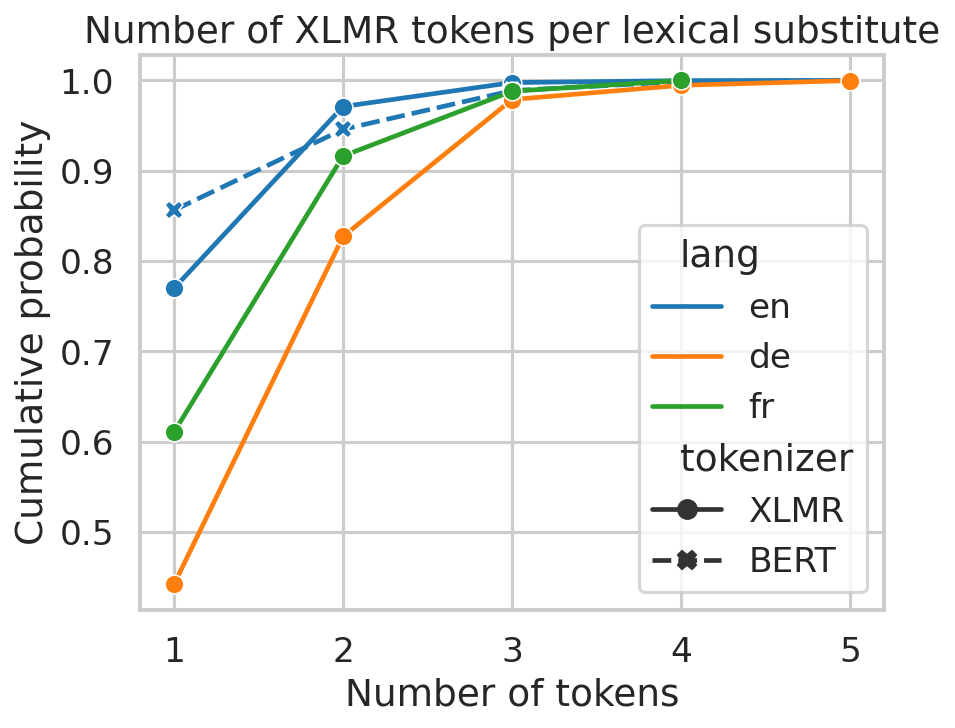

In [9]:
sns.set_context("talk")
dfc = pd.DataFrame(cnts).stack().reset_index()
dfc.columns = ['n_tokens_in_word', 'lang', 'probability']
dfc['tokenizer'] = dfc['lang'].apply(lambda x: x.split(' ')[1])
dfc['lang'] = dfc['lang'].apply(lambda x: x.split(' ')[0])
dfc['cumulative_probability'] = dfc.groupby(['lang', 'tokenizer']).probability.cumsum()
sns.lineplot(data=dfc[dfc.n_tokens_in_word <= 5], x='n_tokens_in_word', y='cumulative_probability', hue='lang', style='tokenizer', markers=True)
plt.title("Number of XLMR tokens per lexical substitute")
plt.xlabel("Number of tokens")
plt.ylabel("Cumulative probability")
plt.xticks(range(1,6))
plt.savefig('tokens_per_subst.png', dpi=200, bbox_inches='tight')

In [ ]:
score[score.part.str.contains(dataset)]

,metric,score,hypers,part


In [ ]:
pd.read_csv(pth2, sep='\t')

,metric,score,hypers,part
0,max_ARI,66.260119,NaN,russe_bts-rnc-ru-train


In [3]:
from collections import defaultdict
import seaborn as sns

metrics = ['max_ARI', 'calinski_harabasz_ARI', ]
datasets=['russe_bts-rnc-ru-train',  'xl_wsd-en-dev', "xl_wsd-sl-dev"]
d = []
params = {
    'cfg': r'(?<=model_vec=subst).*',
    # 'top_k': '(?<=top_k=)\d+','silhouette_ARI'
    # 'min_df': '(?<=min_df=)\d+\.\d+',
    # 'max_df': '(?<=max_df=)\d+\.\d+',
} 


In [101]:
score['metric'] = metric

In [45]:
metric

'max_ARI'

In [4]:
d = []
for f in pth.glob('outputs/*/*final*'):
    s = []
    for param, pattern in params.items():
        value = re.search(pattern, str(f))
        if value:
            s.append(value[0])
    for metric in metrics:
        pth2 = f / 'VectorizingPipeline' / 'agg_metrics' / f"{metric}.tsv"
        if pth2.is_file():
            if metric == 'max_ARI':
                print(pth2)
            score = pd.read_csv(pth2, sep='\t')
            score = score[score.part.isin(datasets)]
            score['metric'] = metric
            score[[param for param in params]] = s
            d.append(score)
        else:
            pth2 = f / 'LexSubGenAdapter' / 'agg_metrics' / f"{metric}.tsv"
            if pth2.is_file():
                if metric == 'max_ARI':
                    print(pth2)
                score = pd.read_csv(pth2, sep='\t')
                score = score[score.part.isin(datasets)]
                score['metric'] = metric
                score[[param for param in params]] = s
                d.append(score)
            # else:
            #     if 'final' in str(f):
            #         print("WHY NOT", f)

df0 = pd.concat(d)
# df0 = pd.DataFrame(d, columns=list(params.keys()) + ['metric', 'value'])
df = df0.drop_duplicates(subset=list(params.keys()) + ['part', 'metric'], keep='last')
df = df.apply(pd.to_numeric, errors='coerce').fillna(df)
if df.shape[0] != df0.shape:
    print('found duplicates')
df

/mnt/d/science/summer-wsi/outputs/2023-06-10_19-18-59/+runname=final,model_vec=subst_123_and/VectorizingPipeline/agg_metrics/max_ARI.tsv
/mnt/d/science/summer-wsi/outputs/2023-06-12_00-40-01/+runname=final,model_vec=subst_123_and/VectorizingPipeline/agg_metrics/max_ARI.tsv
/mnt/d/science/summer-wsi/outputs/2023-06-12_00-40-01/+runname=final,model_vec=subst_123_or/VectorizingPipeline/agg_metrics/max_ARI.tsv
/mnt/d/science/summer-wsi/outputs/2023-06-12_23-50-07/+runname=final,model_vec=subst_cwm_en_or/VectorizingPipeline/agg_metrics/max_ARI.tsv
/mnt/d/science/summer-wsi/outputs/2023-06-14_21-01-24/+runname=final,model_vec=subst_cwm_en_and/VectorizingPipeline/agg_metrics/max_ARI.tsv
/mnt/d/science/summer-wsi/outputs/2023-06-16_00-00-45/+runname=final,model_vec=subst_123_and_also/VectorizingPipeline/agg_metrics/max_ARI.tsv
/mnt/d/science/summer-wsi/outputs/2023-06-16_23-47-36/+runname=final,model_vec=subst_123_and_also/VectorizingPipeline/agg_metrics/max_ARI.tsv
/mnt/d/science/summer-wsi/o

,metric,score,hypers,part,cfg
0,max_ARI,68.883372,NaN,russe_bts-rnc-ru-train,_123_and
4,max_ARI,58.882875,NaN,xl_wsd-en-dev,_123_and
0,calinski_harabasz_ARI,45.542975,NaN,russe_bts-rnc-ru-train,_123_and
4,calinski_harabasz_ARI,33.112620,NaN,xl_wsd-en-dev,_123_and
0,max_ARI,71.317921,NaN,russe_bts-rnc-ru-train,_123_or
...,...,...,...,...,...
1,max_ARI,11.311333,NaN,xl_wsd-sl-dev,_xlmr_cwm_multi_embs
2,max_ARI,50.214494,NaN,xl_wsd-en-dev,_xlmr_cwm_multi_embs
0,calinski_harabasz_ARI,42.460267,NaN,russe_bts-rnc-ru-train,_xlmr_cwm_multi_embs
1,calinski_harabasz_ARI,8.167862,NaN,xl_wsd-sl-dev,_xlmr_cwm_multi_embs


In [10]:
def get_target_injection_method(cfg_name):
    dp_name = {
        # 'part_of': 'SDP "a part of"',
        # 'due_to': 'SDP "due to"',
        # 'for_example': 'SDP "for example"',
        # 'dp_combine': 'SDP combo',
        # 'amrami_multilang': 'BASELINE amrami',
        # '_1_': "BASELINE 1 mask DP",
        'and_also': 'SDP "and also"',
        'or_even': 'SDP "or even"',
        'and': 'SDP "and"',
        '_or': 'SDP "or"',
        'embs': '+embs'
    }
    for dp in dp_name.keys():
        if dp in cfg_name:
            return dp_name[dp]


def get_multimask_method(cfg_name):
    concat_method = {
        # '_1_': "",
        # 'amrami_multilang': '',
        '123': 'concat',
        'cwm_ru_v2': 'WCM-ru',
        # 'cwm_ru': 'WCM RU',
        'cwm_en': 'WCM-en',
        'cwm_multi': 'WCM-multi',
        
    }
    for method in concat_method.keys():
        if method in cfg_name:
            return concat_method[method]

df['target injection'] = df['cfg'].apply(get_target_injection_method)
df['multimask substitutes'] = df['cfg'].apply(get_multimask_method)
df

,metric,score,hypers,part,cfg,target injection,multimask substitutes
0,max_ARI,68.883372,NaN,russe_bts-rnc-ru-train,_123_and,"SDP ""and""",concat
4,max_ARI,58.882875,NaN,xl_wsd-en-dev,_123_and,"SDP ""and""",concat
0,calinski_harabasz_ARI,45.542975,NaN,russe_bts-rnc-ru-train,_123_and,"SDP ""and""",concat
4,calinski_harabasz_ARI,33.112620,NaN,xl_wsd-en-dev,_123_and,"SDP ""and""",concat
0,max_ARI,71.317921,NaN,russe_bts-rnc-ru-train,_123_or,"SDP ""or""",concat
...,...,...,...,...,...,...,...
1,max_ARI,11.311333,NaN,xl_wsd-sl-dev,_xlmr_cwm_multi_embs,+embs,WCM-multi
2,max_ARI,50.214494,NaN,xl_wsd-en-dev,_xlmr_cwm_multi_embs,+embs,WCM-multi
0,calinski_harabasz_ARI,42.460267,NaN,russe_bts-rnc-ru-train,_xlmr_cwm_multi_embs,+embs,WCM-multi
1,calinski_harabasz_ARI,8.167862,NaN,xl_wsd-sl-dev,_xlmr_cwm_multi_embs,+embs,WCM-multi


In [11]:
baseline = df[df.cfg.str.contains('amrami_multilang')]
baseline

,metric,score,hypers,part,cfg,target injection,multimask substitutes
0,max_ARI,45.315960,NaN,russe_bts-rnc-ru-train,_amrami_multilang,None,None
1,max_ARI,14.537803,NaN,xl_wsd-sl-dev,_amrami_multilang,None,None
2,max_ARI,48.522351,NaN,xl_wsd-en-dev,_amrami_multilang,None,None
0,calinski_harabasz_ARI,27.544739,NaN,russe_bts-rnc-ru-train,_amrami_multilang,None,None
1,calinski_harabasz_ARI,4.273690,NaN,xl_wsd-sl-dev,_amrami_multilang,None,None
2,calinski_harabasz_ARI,25.917251,NaN,xl_wsd-en-dev,_amrami_multilang,None,None


In [12]:
def add_patch(legend, ax):
    from matplotlib.patches import Patch

    handles, labels = ax.get_legend_handles_labels()
    handles.append(Patch(facecolor='black'))
    labels.append("Baseline")

    legend._legend_box = None
    legend._init_legend_box(handles, labels)
    legend._set_loc(legend._loc)
    legend.set_title(legend.get_title().get_text())

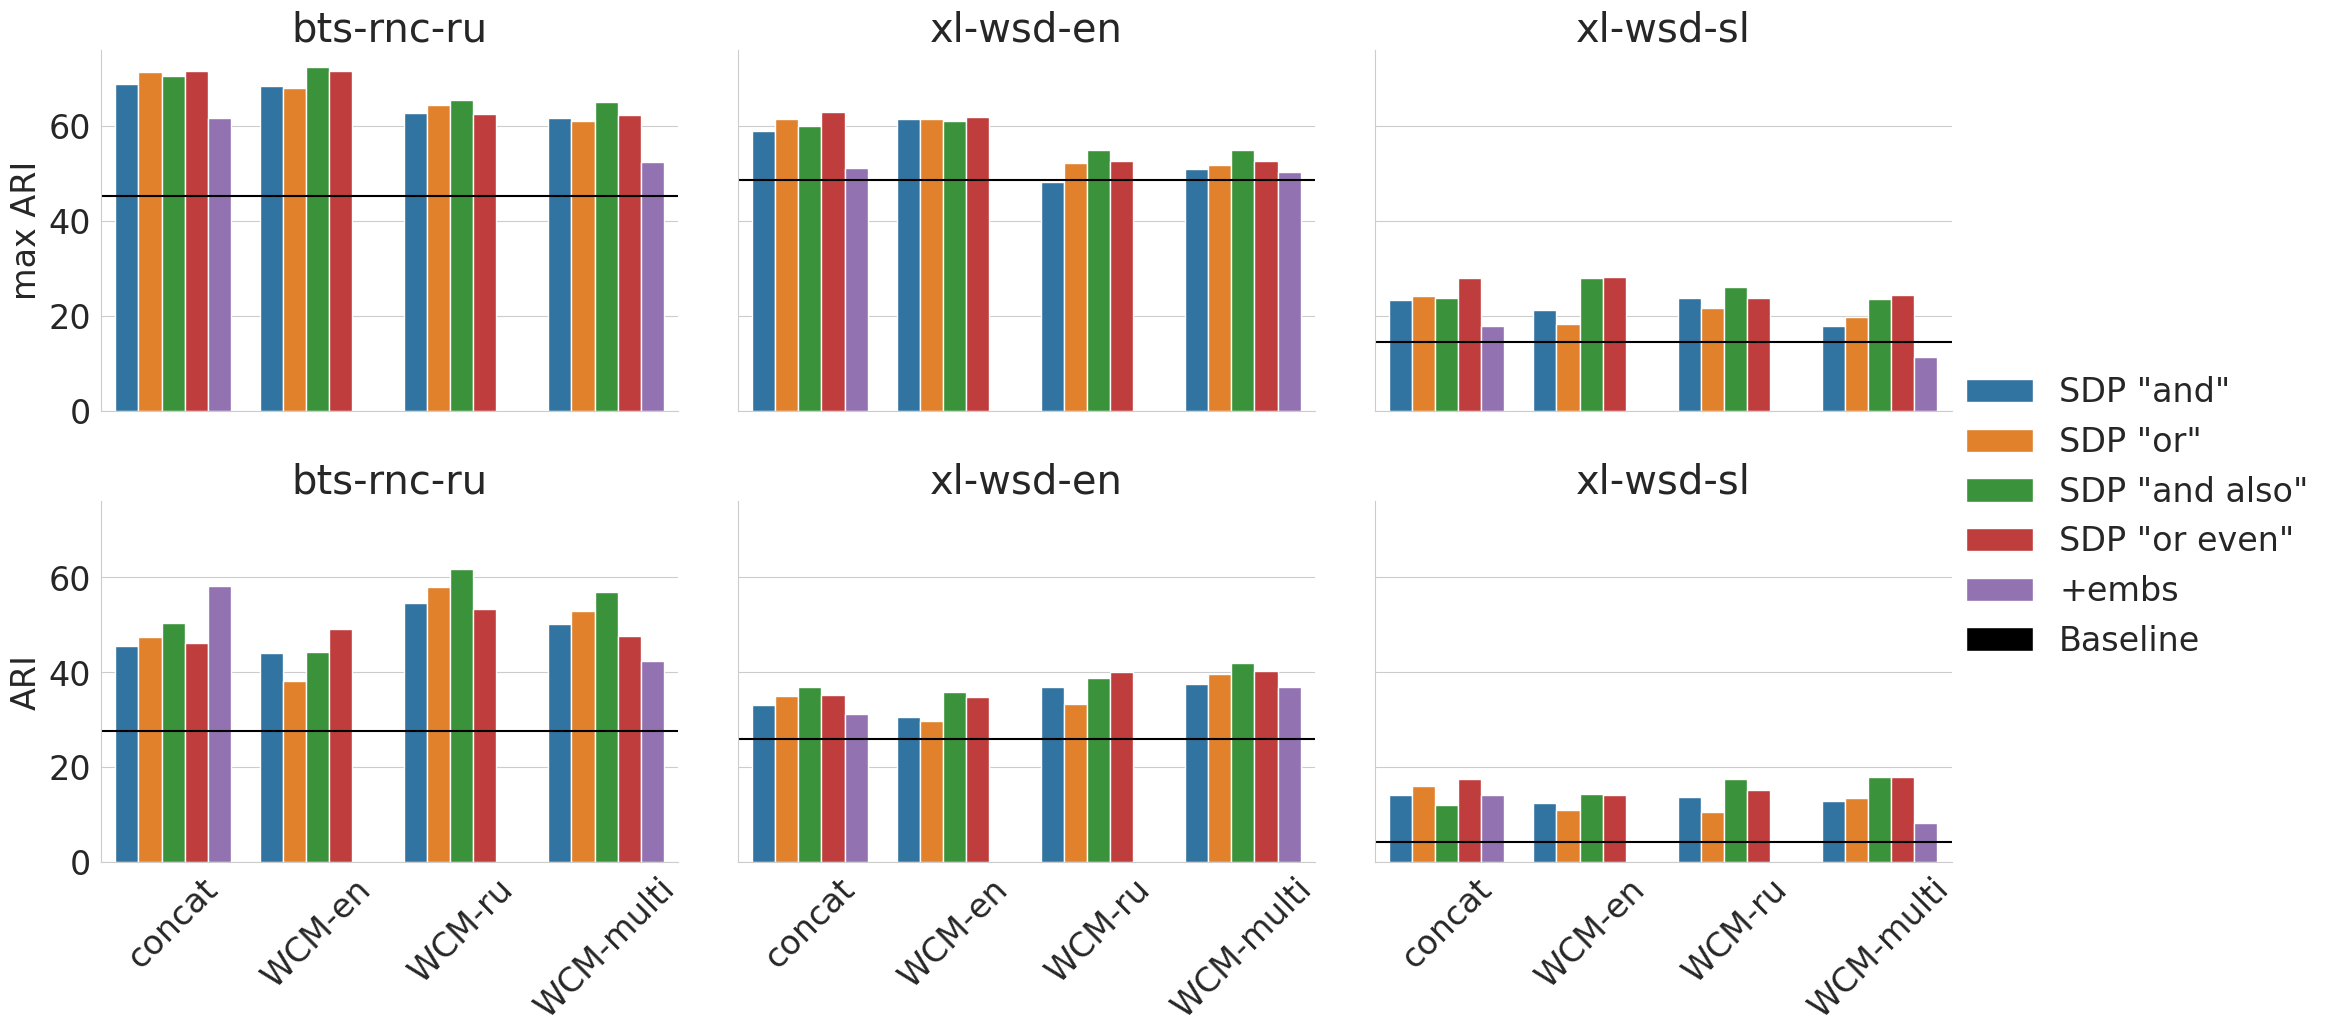

In [15]:
import matplotlib.pyplot as plt


# sns.set_context("talk")
dataset_names = {
    'russe_bts-rnc-ru-train': "bts-rnc-ru",
    'xl_wsd-en-dev': 'xl-wsd-en',
    'xl_wsd-sl-dev': 'xl-wsd-sl'
}

font = {'size' : 24}
matplotlib.rc('font', **font)

plt.rcParams["figure.figsize"] = (20,3)
plt.rcParams["figure.dpi"] = 100
g = sns.catplot(df, hue='target injection', x='multimask substitutes', y='score', col='part', kind='bar', row='metric', aspect=1.35)
g.set_xlabels('')
g.set_titles('{col_name}')
g.tick_params('x', **{'rotation': 45})
for (metric, dataset), ax in g.axes_dict.items():
    val = baseline[(baseline.metric == metric) & (baseline.part == dataset)].iloc[0]['score']
    if 'russe' in dataset:
        ax.set_ylabel('max ARI' if 'max' in metric else 'ARI')
    ax.axhline(val, color='black')
    ax.set_title(dataset_names[dataset])
add_patch(g._legend, ax)
plt.savefig('dev ARI.png', dpi=150, bbox_inches="tight")
    # hline_text(-0.1, val, 'BASELINE', ax=ax)

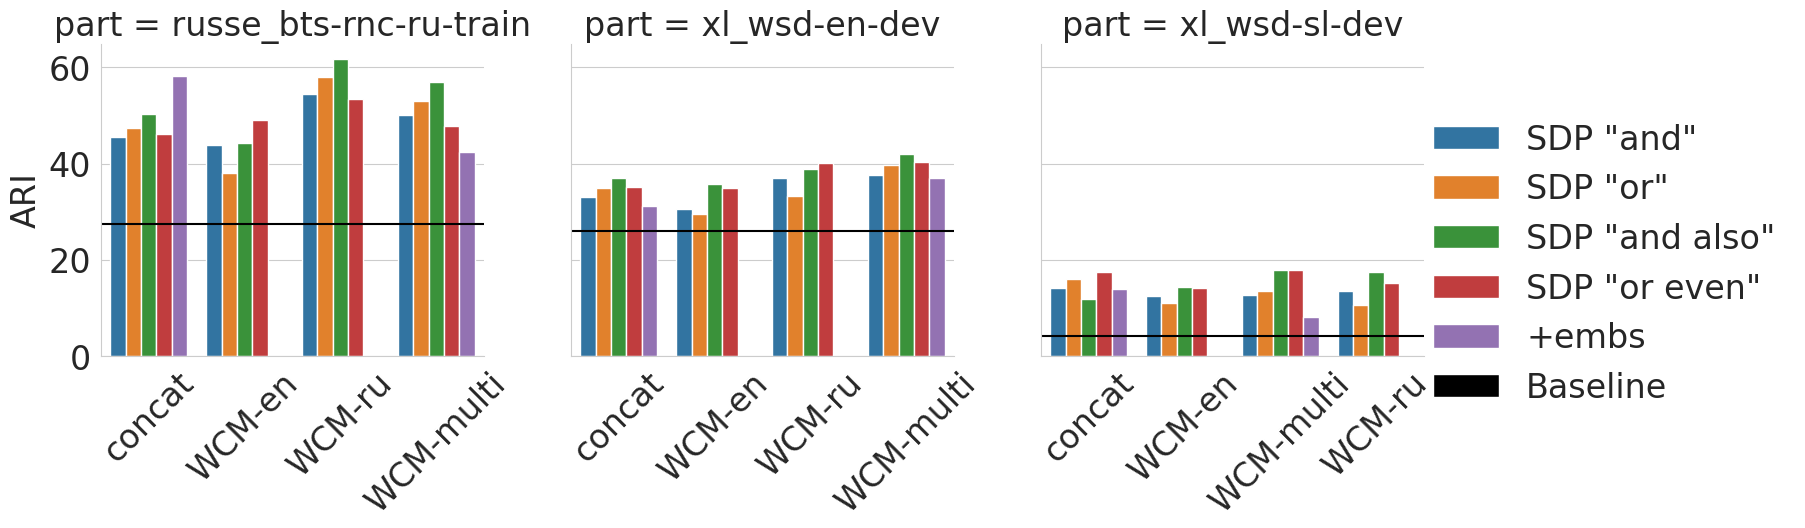

In [14]:
import matplotlib.pyplot as plt
metric = 'calinski_harabasz_ARI'
plt.rcParams["figure.figsize"] = (20,3)
plt.rcParams["figure.dpi"] = 100
g = sns.catplot(df[df['metric'] == metric], hue='target injection', x='multimask substitutes', y='score', col='part', kind='bar', sharex=False)
g.set_ylabels('ARI')
g.set_xlabels('')
g.tick_params('x', **{'rotation': 45})
for dataset, ax in g.axes_dict.items():
    val = baseline[(baseline.metric == metric) & (baseline.part == dataset)].iloc[0]['score']
    ax.axhline(val, color='black')
add_patch(g._legend, ax)
plt.savefig('dev ARI.png', dpi=150, bbox_inches="tight")
    # hline_text(-0.1, val, 'BASELINE', ax=ax)

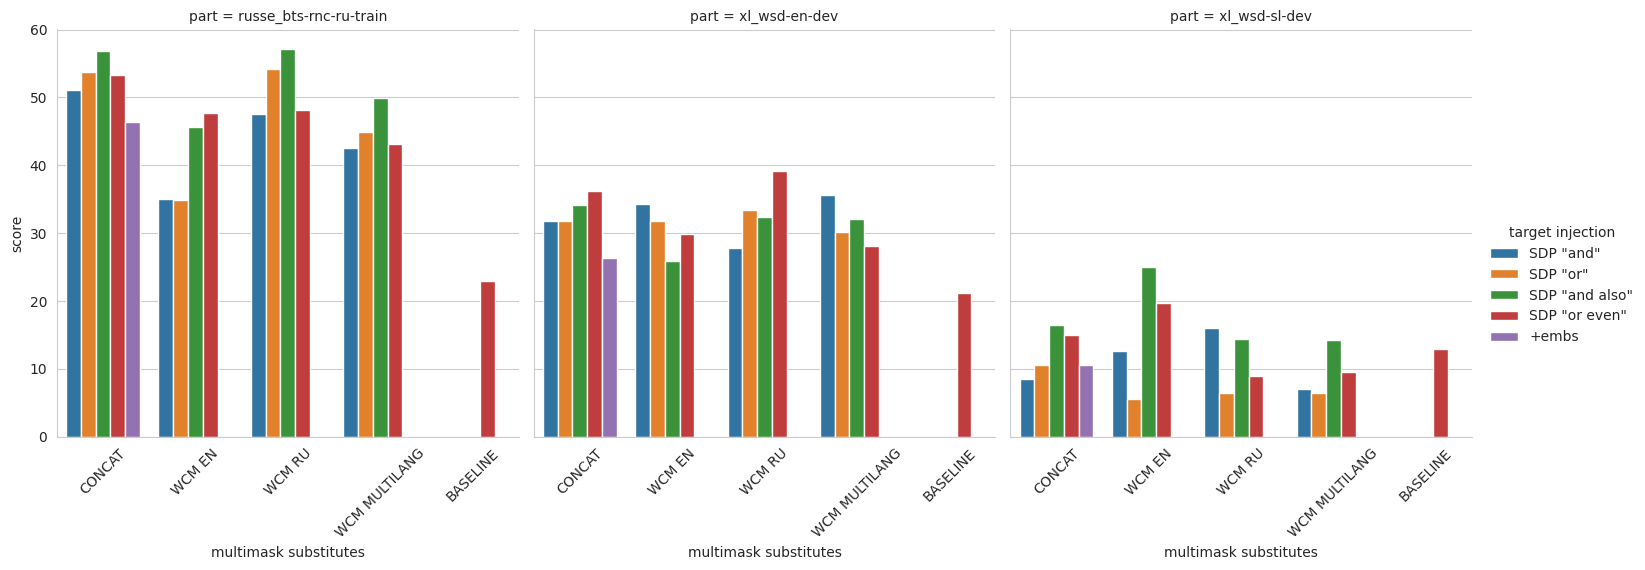

In [40]:
g = sns.catplot(df[df['metric'] == 'silhouette_ARI'], hue='target injection', x='multimask substitutes',
                y='score', col='part', kind='bar')
g.tick_params('x', **{'rotation': 45})

In [17]:
df

,metric,score,hypers,part,top_k,temp
0,max_ARI,49.626027,NaN,russe_bts-rnc-ru-train,10,0
0,calinski_harabasz_ARI,40.477031,NaN,russe_bts-rnc-ru-train,10,0
0,silhouette_ARI,37.605820,NaN,russe_bts-rnc-ru-train,10,0
0,max_ARI,54.180528,NaN,russe_bts-rnc-ru-train,100,0
0,calinski_harabasz_ARI,42.268133,NaN,russe_bts-rnc-ru-train,100,0
0,silhouette_ARI,30.116359,NaN,russe_bts-rnc-ru-train,100,0
0,max_ARI,55.481910,NaN,russe_bts-rnc-ru-train,110,0
0,calinski_harabasz_ARI,43.445765,NaN,russe_bts-rnc-ru-train,110,0
0,silhouette_ARI,35.621877,NaN,russe_bts-rnc-ru-train,110,0
0,max_ARI,55.700006,NaN,russe_bts-rnc-ru-train,120,0


<Axes: xlabel='top_k', ylabel='score'>

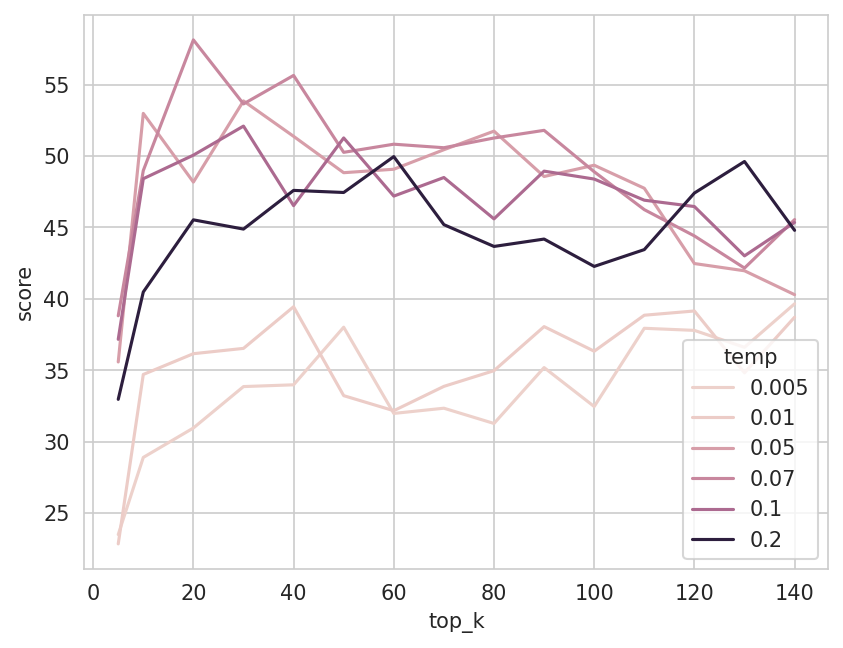

In [23]:
sns.lineplot(data=df[df.metric=='calinski_harabasz_ARI'], x='top_k', y='score', hue='temp')

In [15]:
plot_data = df[df.metric == 'max_ARI']
sns.relplot(data=plot_data, x='top_k', y='value', hue='temp', row=plot_data['min_df'], col=plot_data['max_df'], kind='line')

KeyError: 'min_df'

In [ ]:
'xl_wsd-multilang-dev', 'russe_bts-rnc-ru-train', 'xl_wsd-en-dev',

('xl_wsd-multilang-dev', 'russe_bts-rnc-ru-train', 'xl_wsd-en-dev')

_cwm_large_en [(5.0, 17.734802279854755), (10.0, 18.920899701631583), (20.0, 27.646296637432688), (30.0, 27.547570417112446), (40.0, 29.612988257069304), (50.0, 36.34878438257679), (70.0, 28.32249715321028), (80.0, 33.21525157189521), (90.0, 31.54097961469014), (110.0, 37.70990667115809), (120.0, 32.56383730493308), (130.0, 30.12640341488457), (140.0, 34.05414970916812), (150.0, 33.39343352140428)]


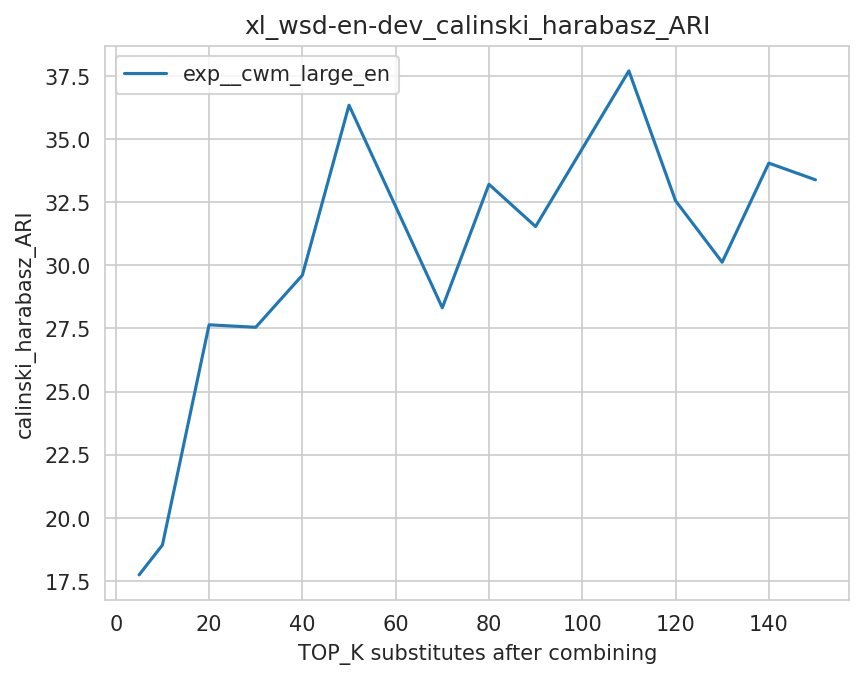

In [36]:
from collections import defaultdict

# metric = 'max_ARI'
metric = 'calinski_harabasz_ARI'
dataset='xl_wsd-en-dev'
d = defaultdict(list)

for f in pth.glob('outputs/*/*experiment0905*'):
    thr = re.search('(?<=top_k=)\d+', str(f))
    if thr:
        thr = thr[0]
        name = re.search(r'(?<=model_vec=subst_rombek).*', str(f))
        if name:
            name = name[0]
            if 'nummasks=2' in str(f):
                name += 'nm2'
            if 'side=right' in str(f):
                name += 'R'
            if 'mask_count' in str(f):
                name += re.search(r'(?<=mask_count=\[).*\]', str(f))[0]
            # print(name, thr)
            pth2 = f / 'VectorizingPipeline' / 'agg_metrics' / f"{metric}.tsv"
            if pth2.is_file():
                score = pd.read_csv(pth2, sep='\t')
                score = score[score.part == (dataset)]['score']
                if score.shape[0] > 0:
                    score = score.iloc[0]
                    if float(thr) not in [t[0] for t in d[name]]:
                        d[name].append((float(thr), score))
                    else:
                        print(f'skipping {f}')
            pth2 = f / 'LexSubGenAdapter' / 'agg_metrics' / f"{metric}.tsv"
            if pth2.is_file():
                score = pd.read_csv(pth2, sep='\t')
                score = score[score.part == (dataset)]['score']
                if score.shape[0] > 0:
                    score = score.iloc[0]
                    if float(thr) not in [t[0] for t in d[name]]:
                        d[name].append((float(thr), score))
                    else:
                        print(f'skipping {f}')
        d

for name, values in d.items():
    values = sorted(values, key=lambda x: x[0])
    print(name, values)
    plt.plot([t[0] for t in values], [t[1] for t in values], label="exp_" + name)
plt.ylabel(metric)
plt.title(f"{dataset}_{metric}")
plt.xlabel(f"TOP_K substitutes after combining")
plt.legend()

_123_and [(10.0, 51.81170462635961), (20.0, 57.303962280563226), (30.0, 56.56967277563727), (40.0, 63.40990401456189), (50.0, 62.85255961534232), (60.0, 62.88130684428717), (70.0, 63.108153458592525), (80.0, 61.56506397656546), (90.0, 61.78891290742889), (100.0, 62.902772057387104), (110.0, 64.32187574854676), (120.0, 63.91555787660647), (130.0, 64.02168085423426), (140.0, 61.56206606983999)]
_123_and_also [(10.0, 56.20205163096208), (20.0, 62.88507249281309), (30.0, 66.3891358507358), (40.0, 65.79412052195674), (50.0, 66.00425728437033), (60.0, 66.68369747276236), (70.0, 66.8907138102696), (80.0, 66.86994633930254), (90.0, 65.62768277384716), (100.0, 66.08210449076017), (110.0, 66.45015588234381), (120.0, 66.11689185584709), (130.0, 65.47445810335446), (140.0, 66.63416122304677)]
_123_or [(10.0, 56.25909447342588), (20.0, 59.00885273379799), (30.0, 61.01359268474993), (40.0, 64.13805889699131), (50.0, 63.14326615378279), (60.0, 64.20589779581866), (70.0, 64.9833099649098), (80.0, 63.5

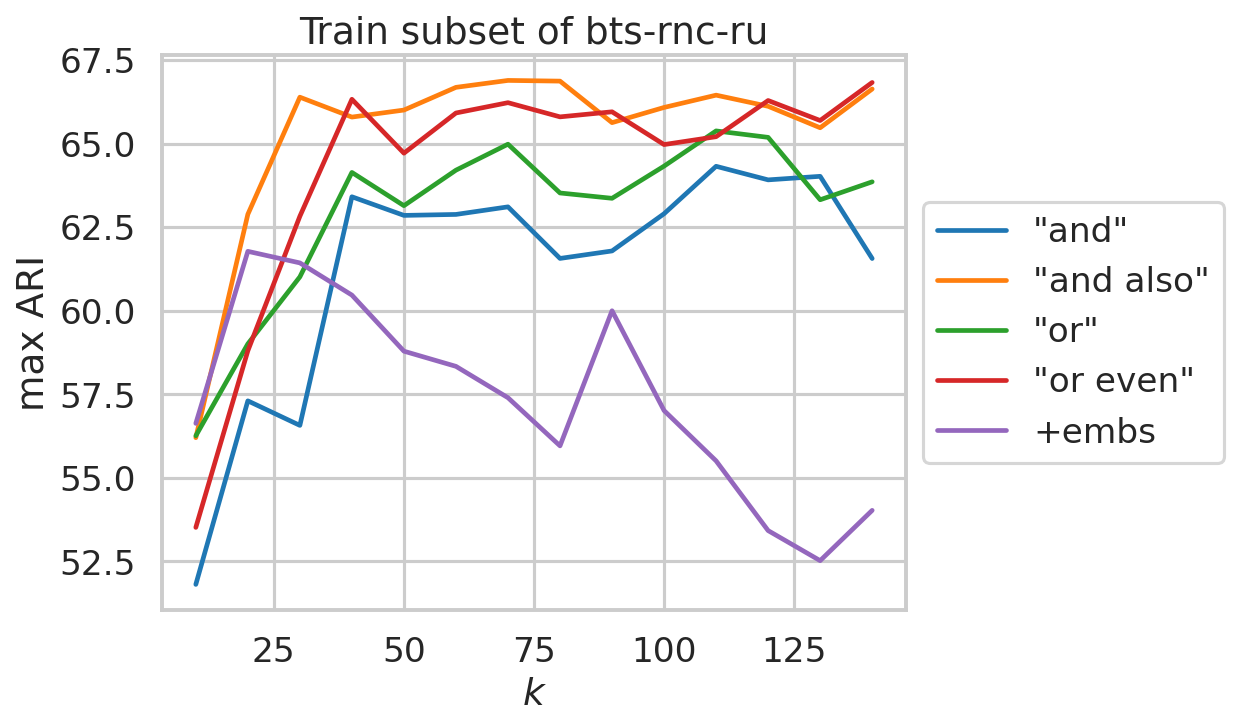

In [14]:
from collections import defaultdict

metric = 'max_ARI'
dataset= 'russe_bts-rnc-ru-train'
d = defaultdict(list)

for f in pth.glob('outputs/*/*experiment_topk*'):
    thr = re.search('(?<=top_k=)\d+', str(f))
    if thr:
        thr = thr[0]
        if int(thr) < 150:
            name = re.search(r'(?<=model_vec=subst).*', str(f))

            if name:
                name = name[0]
                name = name.replace('rombek_', '')
                if 'nummasks=2' in str(f):
                    name += 'nm2'
                if 'side=right' in str(f):
                    name += 'R'
                if 'mask_count' in str(f):
                    name += re.search(r'(?<=mask_count=\[).*\]', str(f))[0]
                # print(name, thr)
                pth2 = f / 'VectorizingPipeline' / 'agg_metrics' / f"{metric}.tsv"
                if pth2.is_file():
                    score = pd.read_csv(pth2, sep='\t')
                    score = score[score.part.str.contains(dataset)]['score']
                        
                    if score.shape[0] > 0:
                        score = score.iloc[0]
                        if float(thr) not in [t[0] for t in d[name]] and float(thr) > 5:
                            d[name].append((float(thr), score))
                        else:
                            print(f'skipping {f}')
            else:
                name = re.search(r'(?<=model_vec=lexsubgen).*', str(f))
                if name:
                    name = "_CONCAT+embs"
                    # print(name, thr)
                    pth2 = f / 'LexSubGenAdapter' / 'agg_metrics' / f"{metric}.tsv"
                    if pth2.is_file():
                        score = pd.read_csv(pth2, sep='\t')
                        score = score[score.part.str.contains(dataset)]['score']

                        if score.shape[0] > 0:
                            score = score.iloc[0]
                            if float(thr) not in [t[0] for t in d[name]]  and float(thr) > 5:
                                d[name].append((float(thr), score))
                            else:
                                print(f'skipping {f}')

names = {
    # '_123_dp_combine':  'CONCAT SDP combine',
    '_123':  'concat SDP "or even"',
}
names = {
    '_123_and': '"and"',
    '_123_or': '"or"',
    '_123_and_also': '"and also"',
    '_123_or_even': '"or even"',
    '_CONCAT+embs': '+embs',
}
for name in d:
    values = d[name]
    values = sorted(values, key=lambda x: x[0])
    print(name, values)
    plt.plot([t[0] for t in values], [t[1] for t in values], label=names[name])
plt.ylabel(metric.replace('_', ' '))
plt.title(f"Train subset of bts-rnc-ru")
plt.xlabel(f"$k$")
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.savefig('topk.png', dpi=150, bbox_inches='tight')

skipping /mnt/d/science/summer-wsi/outputs/2023-05-09_16-34-15/+runname=experiment0905,model_vec.vec_config.top_k=5,model_vec=subst_rombek_2
skipping /mnt/d/science/summer-wsi/outputs/2023-06-09_10-18-11/+runname=experiment0905,model_vec.vec_config.top_k=5,model_vec=subst_rombek_cwm_large_en
skipping /mnt/d/science/summer-wsi/outputs/2023-09-19_12-33-40/+runname=experiment0905,model_vec.base_substgen.top_k=5,model_vec=lexsubgen
skipping /mnt/d/science/summer-wsi/outputs/2023-09-29_16-12-31/+runname=experiment0905,model_vec.vec_config.top_k=5,model_vec=subst_123_dp_combine
_1 [(10.0, 26.535327168937226), (20.0, 35.1417402255731), (30.0, 39.52159192053136), (40.0, 35.897967166008954), (60.0, 37.46402724168384), (70.0, 32.83796507573006), (90.0, 33.27151369654131), (100.0, 30.93489709993568), (110.0, 31.27979443789929), (120.0, 32.90300462199645), (130.0, 33.10878320395695), (140.0, 32.03578694623917)]
_123 [(10.0, 28.51213331897827), (20.0, 36.9025408408963), (50.0, 47.12964245854757), (

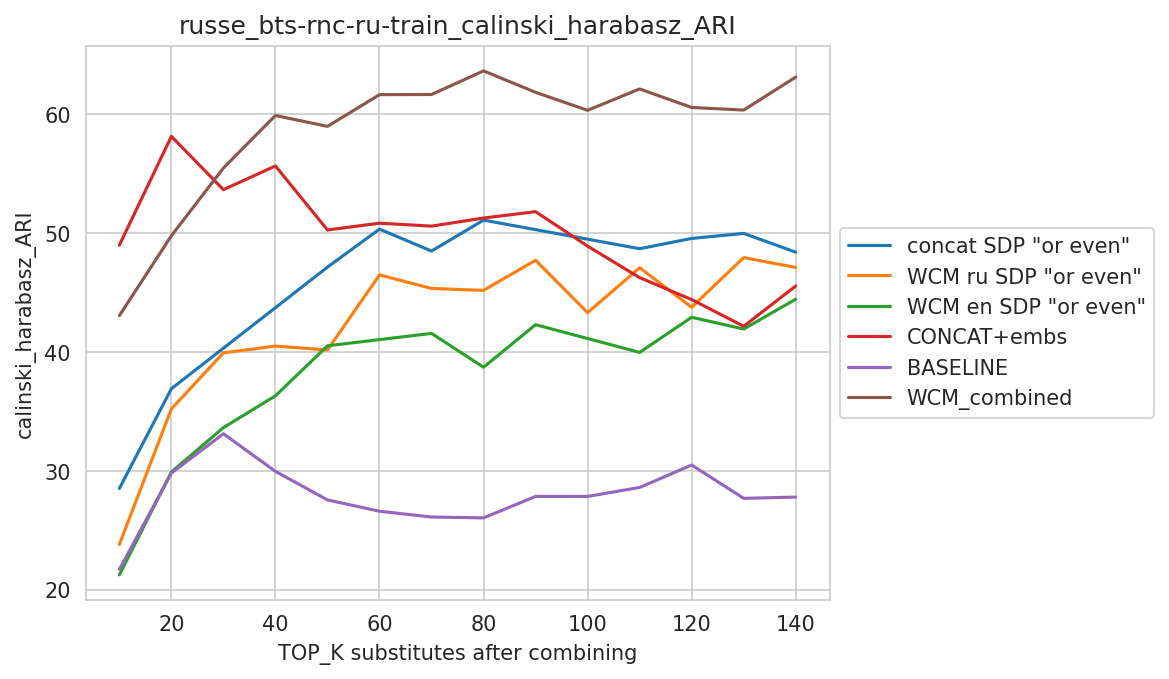

In [7]:
from collections import defaultdict

metric = 'calinski_harabasz_ARI'
dataset= 'russe_bts-rnc-ru-train'
d = defaultdict(list)

for f in pth.glob('outputs/*/*experiment0905*'):
    thr = re.search('(?<=top_k=)\d+', str(f))
    if thr:
        thr = thr[0]
        if int(thr) < 150:
            name = re.search(r'(?<=model_vec=subst).*', str(f))

            if name:
                name = name[0]
                name = name.replace('rombek_', '')
                if 'nummasks=2' in str(f):
                    name += 'nm2'
                if 'side=right' in str(f):
                    name += 'R'
                if 'mask_count' in str(f):
                    name += re.search(r'(?<=mask_count=\[).*\]', str(f))[0]
                # print(name, thr)
                pth2 = f / 'VectorizingPipeline' / 'agg_metrics' / f"{metric}.tsv"
                if pth2.is_file():
                    score = pd.read_csv(pth2, sep='\t')
                    score = score[score.part.str.contains(dataset)]['score']

                    if score.shape[0] > 0:
                        score = score.iloc[0]
                        if float(thr) not in [t[0] for t in d[name]] and float(thr) > 5:
                            d[name].append((float(thr), score))
                        else:
                            print(f'skipping {f}')
            else:
                name = re.search(r'(?<=model_vec=lexsubgen).*', str(f))
                if name:
                    name = "_CONCAT+embs"
                    # print(name, thr)
                    pth2 = f / 'LexSubGenAdapter' / 'agg_metrics' / f"{metric}.tsv"
                    if pth2.is_file():
                        score = pd.read_csv(pth2, sep='\t')
                        score = score[score.part.str.contains(dataset)]['score']

                        if score.shape[0] > 0:
                            score = score.iloc[0]
                            if float(thr) not in [t[0] for t in d[name]]  and float(thr) > 5:
                                d[name].append((float(thr), score))
                            else:
                                print(f'skipping {f}')

names = {
    # '_123_dp_combine':  'CONCAT SDP combine',
    '_123':  'concat SDP "or even"',
    '_cwm_large_v2': 'WCM ru SDP "or even"',
    '_cwm_large_en': 'WCM en SDP "or even"',
    '_cwm_multi': 'WCM multi SDP "or even"',
    '_1_or_even': 'BASELINE',
    '_CONCAT+embs': 'CONCAT+embs',
    '_123_giga': 'WCM_combined'
}
for name, values in d.items():
    values = sorted(values, key=lambda x: x[0])
    print(name, values)
    if name not in ['_1', '_2', '_cwm_large', '_123_dp_combine']:
        plt.plot([t[0] for t in values], [t[1] for t in values], label=names[name])
plt.ylabel(metric)
plt.title(f"{dataset}_{metric}")
plt.xlabel(f"TOP_K substitutes after combining")
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))

In [ ]:
from collections import defaultdict

metric = 'max_ARI'
dataset= 'russe_bts-rnc-ru-train'
d = defaultdict(list)

for f in pth.glob('outputs/*/*tempopt*'):
    thr = re.search('(?<=top_k=)\d+', str(f))
    if thr:
        thr = thr[0]
        if int(thr) < 150:
            name = re.search(r'(?<=model_vec=subst).*', str(f))

            if name:
                name = name[0]
                name = name.replace('rombek_', '')
                if 'nummasks=2' in str(f):
                    name += 'nm2'
                if 'side=right' in str(f):
                    name += 'R'
                if 'mask_count' in str(f):
                    name += re.search(r'(?<=mask_count=\[).*\]', str(f))[0]
                # print(name, thr)
                pth2 = f / 'VectorizingPipeline' / 'agg_metrics' / f"{metric}.tsv"
                if pth2.is_file():
                    score = pd.read_csv(pth2, sep='\t')
                    score = score[score.part.str.contains(dataset)]['score']

                    if score.shape[0] > 0:
                        score = score.iloc[0]
                        if float(thr) not in [t[0] for t in d[name]] and float(thr) > 5:
                            d[name].append((float(thr), score))
                        else:
                            print(f'skipping {f}')
            else:
                name = re.search(r'(?<=model_vec=lexsubgen).*', str(f))
                if name:
                    name = "_CONCAT+embs"
                    # print(name, thr)
                    pth2 = f / 'LexSubGenAdapter' / 'agg_metrics' / f"{metric}.tsv"
                    if pth2.is_file():
                        score = pd.read_csv(pth2, sep='\t')
                        score = score[score.part.str.contains(dataset)]['score']

                        if score.shape[0] > 0:
                            score = score.iloc[0]
                            if float(thr) not in [t[0] for t in d[name]]  and float(thr) > 5:
                                d[name].append((float(thr), score))
                            else:
                                print(f'skipping {f}')

names = {
    '_123':  'CONCAT SDP "or even"',
    '_cwm_large_v2': 'CWM RU SDP "or even"',
    '_cwm_large_en': 'CWM EN SDP "or even"',
    '_1_or_even': 'BASELINE',
    '_CONCAT+embs': 'CONCAT+embs'

}
for name, values in d.items():
    values = sorted(values, key=lambda x: x[0])
    print(name, values)
    if name not in ['_1', '_2', '_cwm_large']:
        plt.plot([t[0] for t in values], [t[1] for t in values], label=names[name])
plt.ylabel(metric)
plt.title(f"{dataset}_{metric}")
plt.xlabel(f"TOP_K substitutes after combining")
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))

_1 [(10.0, 5.139544423434389), (20.0, 8.62169910443404), (30.0, 8.321068683832266), (40.0, 5.6364964920183), (60.0, 6.419381735844127), (70.0, 6.460192213179472), (90.0, 5.194998758257369), (100.0, 6.037132245071068), (110.0, 4.396360797234397), (120.0, 5.147799019372248), (130.0, 5.355049781038806), (140.0, 5.730779583560543)]
_123 [(10.0, 6.082197293031072), (20.0, 8.108404207262641), (50.0, 6.490751125138256), (60.0, 9.012133985481492), (70.0, 10.071616681473062), (80.0, 10.27197548379149), (110.0, 8.851700926693479), (120.0, 8.82324497318391), (130.0, 10.448972607764857), (140.0, 10.461241863378367)]
_2 [(5.0, 2.8997004614330675), (10.0, 3.859591179661453), (20.0, 5.001391443255525), (30.0, 5.224645172064655), (40.0, 5.735641809361601), (50.0, 6.466264127975856), (60.0, 8.095854343631654), (70.0, 8.990345767454615), (80.0, 9.353308654801864), (90.0, 10.215320213807791), (100.0, 9.498676392642723), (110.0, 10.27599769881601), (120.0, 11.460798014318485), (130.0, 10.780040963716752),

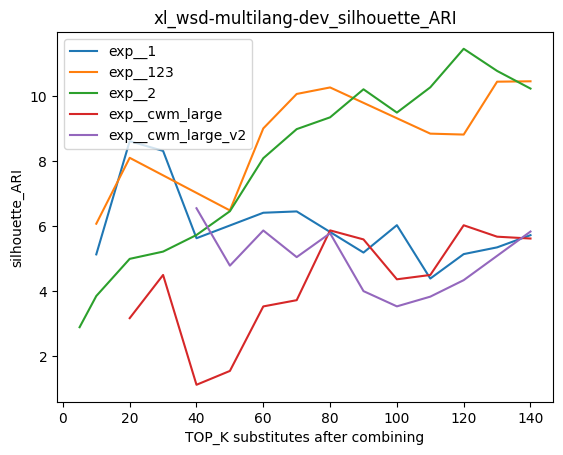

In [ ]:
from collections import defaultdict

metric = 'silhouette_ARI'
d = defaultdict(list)

for f in pth.glob('*experiment0905*'):
    thr = re.search('(?<=top_k=)\d+', str(f))
    if thr:
        thr = thr[0]
        if int(thr) < 150:
            name = re.search(r'(?<=model_vec=subst_rombek).*', str(f))
            if name:
                name = name[0]
                if 'nummasks=2' in str(f):
                    name += 'nm2'
                if 'side=right' in str(f):
                    name += 'R'
                if 'mask_count' in str(f):
                    name += re.search(r'(?<=mask_count=\[).*\]', str(f))[0]
                # print(name, thr)
                pth2 = f / 'VectorizingPipeline' / 'agg_metrics' / f"{metric}.tsv"
                if pth2.is_file():
                    score = pd.read_csv(pth2, sep='\t')
                    score = score[score.part.str.contains(dataset)]['score']
                    
                    if score.shape[0] > 0:
                        score = score.iloc[0]
                        if float(thr) not in [t[0] for t in d[name]]:
                            d[name].append((float(thr), score))
                        else:
                            print(f'skipping {f}')
for name, values in d.items():
    values = sorted(values, key=lambda x: x[0])
    print(name, values)
    plt.plot([t[0] for t in values], [t[1] for t in values], label="exp_" + name)
plt.ylabel(metric)
plt.title(f"{dataset}_{metric}")
plt.xlabel(f"TOP_K substitutes after combining")
plt.legend()

In [ ]:
import numpy as np


# substs = np.load(r'D:\science\summer-wsi\SubstWSI_rombek\substs\ru\2023-05-08_17-14-40-limitNone-maxexperwordNone-maxlen510\modelxlmr_large_model.pt-beamsearchFalse-contgreedyTrue-version3\T-(а-также-_mask__mask_)-2ltr2f0s_topk150_fixspacesTrue.npz')
# substs
substs = np.load(r'D:\science\summer-wsi\SubstWSI_rombek\substs\ru\2023-04-07_00-46-04-limitNone-maxexperwordNone-maxlen510\modelxlmr_large_model.pt-beamsearchFalse-contgreedyTrue-version3\_mask__mask_-(а-также-T)-2ltr2f0s_topk1000_fixspacesTrue.npz')
substs

In [ ]:
for k in substs.files:
     print(k)

substs
probs


In [ ]:
substs['substs'][1].shape

(1000,)

In [ ]:
from collections import defaultdict
import seaborn as sns

metrics = ['fh_max_ARI']
dataset='russe_bts-rnc-ru-train'
d = []
params = {
    'cfg': r'(?<=model_vec=subst_ru_top).*',
    'top_k': '(?<=top_k=)\d+',
} 

for f in pth.glob('*top1000CLR*'):
    s = []
    for param, pattern in params.items():
        value = re.search(pattern, str(f))
        if value:
            s.append(value[0])
    for metric in metrics:
        pth2 = f / 'VectorizingPipeline' / 'agg_metrics' / f"{metric}.tsv"
        if pth2.is_file():
            score = pd.read_csv(pth2, sep='\t')
            score = score[score.part == (dataset)]['score'].iloc[0]
            d.append(s + [metric, score])

df0 = pd.DataFrame(d, columns=list(params.keys()) + ['metric', 'value'])
df = df0.drop_duplicates(subset=list(params.keys()) + ['metric'])
df = df.apply(pd.to_numeric, errors='coerce').fillna(df)
if df.shape[0] != df0.shape[0]:
    print('found duplicates')
df0

,cfg,top_k,metric,value
0,1000,100,fh_max_ARI,58.937731
1,1000l,100,fh_max_ARI,49.773801
2,1000r,100,fh_max_ARI,47.492078
3,1000,1000,fh_max_ARI,51.822725
4,1000l,1000,fh_max_ARI,32.639672
...,...,...,...,...
103,1000l,900,fh_max_ARI,35.939213
104,1000r,900,fh_max_ARI,44.376556
105,1000,950,fh_max_ARI,49.137917
106,1000l,950,fh_max_ARI,33.197274


Text(0.5, 1.0, 'russe_bts-rnc-ru-train')

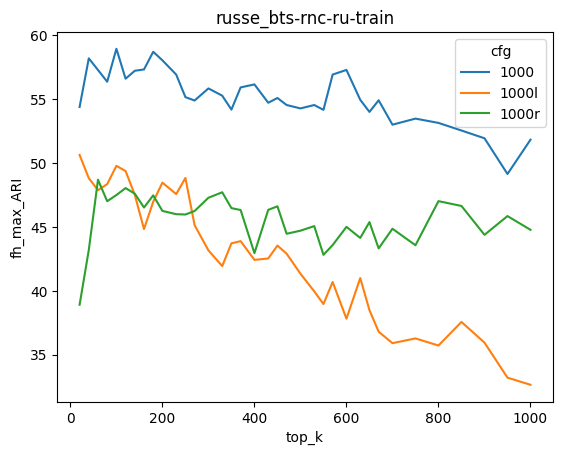

In [ ]:
sns.lineplot(data=df0.astype({'top_k': int}), x='top_k', y='value', hue='cfg')
plt.ylabel(metric)
plt.title(dataset)

In [19]:
a = np.load(r"/mnt/d/science/summer-wsi/SubstWSI_rombek/substs/ru/2023-07-03_04-13-01-limitNone-maxexperwordNone-maxlen510/modelxlmr_large_cwm_en_model.pt-beamsearchTrue-contgreedyTrue-version4/T-(или-даже-_mask__mask__mask_)-2ltr3f0s_topk150_fixspacesTrue.npz")
a['substs']

array([[' stories', ' truths', ' tales', ..., ' lgg', ' photostatis',
        ' blogsocks'],
       [' MORELY', ' stories-like', ' BEST', ..., ' GODSOUR', ' PSALES',
        ' rather-be'],
       [' jokes', ' stories', ' truths', ..., ' merseas', ' memory-game',
        ' yaya-'],
       ...,
       [' bigger', ' pistols?', ' smaller', ..., ' parisis', ' haas-',
        ' mazzami'],
       [' two-piece', ' one', ' more', ..., ' lb;', ' glass-bot',
        ' otherwiseo-'],
       [' bullet-', ' something', ' one', ..., ' merel-', ' serf-',
        ' potwork-']], dtype='<U23')

In [13]:
pd.read

UnpicklingError: Failed to interpret file '/mnt/d/science/summer-wsi/SubstWSI_rombek/substs/ru/2023-07-03_04-13-01-limitNone-maxexperwordNone-maxlen510/modelxlmr_large_cwm_en_model.pt-beamsearchTrue-contgreedyTrue-version4/T-(или-даже-_mask__mask__mask_)-2ltr3f0s_topk150_fixspacesTrue.npz.input' as a pickle

In [23]:
a = np.load(r"/mnt/d/science/summer-wsi/SubstWSI_rombek/substs/it/2023-08-30_00-47-12-limitNone-maxexperwordNone-maxlen510/modelxlmr_large_cwm_multi_model.pt-beamsearchTrue-contgreedyTrue-version4/T-(nonché-_mask__mask__mask_)-2ltr3f0s_topk150_fixspacesTrue.npz")
a['substs']

array([[' large', ' substantial', ' good', ..., ' mite--', ' godo-g',
        ' estest-a'],
       [' lot', ' amount', ' much', ..., ' uunkg', ' aft-the',
        ' emeatng'],
       [' wsome', ' ught', ' n', ..., ' what????', ' (a)n',
        ' protgically'],
       ...,
       [' a', ' very', ' the', ..., ' paw--', ' beasts:', ' daft-da'],
       [' distant', ' uncertain', ' promiscuous', ..., ' g-g-',
        ' d-pack-', ' arcade-like'],
       [' distant', ' beautiful', ' mountain', ..., ' ox-a', ' w-E-',
        ' naga-na']], dtype='<U25')

In [24]:
df = pd.read_csv("/mnt/d/science/summer-wsi/SubstWSI_rombek/substs/it/2023-08-29_09-19-47-limitNone-maxexperwordNone-maxlen510/modelxlmr_large_cwm_model.pt-beamsearchTrue-contgreedyTrue-version4/T-(o-anche-_mask__mask__mask_)-2ltr3f0s_topk150_fixspacesTrue.npz")
df

,context,word,lang,positions
0,有害廃棄物のかなりの量は、港に廃棄される.,かなり,ja,"(6, 9)"
1,その問題にかなりの時間を費やした.,かなり,ja,"(5, 8)"
2,天気はかなり寒かった.,かなり,ja,"(3, 6)"
3,白に部屋を塗ることで、部屋をかなり （ 実質的に ） 大きく見せた.,かなり,ja,"(14, 17)"
4,かなり大きい.,かなり,ja,"(0, 3)"
...,...,...,...,...
103,遠い旅.,遠い,ja,"(0, 2)"
104,地球の遠い隅.,遠い,ja,"(3, 5)"
105,遠い長旅.,遠い,ja,"(0, 2)"
106,遠い未来.,遠い,ja,"(0, 2)"


In [ ]:
# it index 7 17

In [27]:
from sklearn.model_selection import ParameterGrid
from tqdm.notebook import tqdm
import joblib

def check(a):
    a = np.array(params.values())
    if a.sum() != 120:
        return False
    else:
        votes = 0
        for i in range(1, 6):
            if a[i] < a[i-1] and a[i] < a[(i+1)%6]:
                votes += 1
        if votes >= 3:
            print(a)
            return True
        else:
            return False

grid = {
    j:[i for i in range(120)] for j in range(6)
}
joblib.Parallel(10)(joblib.delayed(check)(a) for a in tqdm(ParameterGrid(grid)))

  0%|          | 0/2985984000000 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [30]:
sum([1/2*(3/4)**i for i in range(100)])

1.999999999999358

In [21]:
paths = [
    r"../..\outputs\2023-09-19_11-38-18\+runname=experiment0905,model_vec.base_substgen.top_k=20,model_vec=lexsubgen".replace('\\', '/'),
    r"../..\outputs\2023-09-19_11-38-18\+runname=experiment0905,model_vec.base_substgen.top_k=150,model_vec=lexsubgen".replace('\\', '/')
]
t = []
for i, path in enumerate(paths):
    path = Path(path) / 'LexSubGenAdapter' / 'word_metrics'
    for word in os.listdir(path):
        df_word = pd.read_csv(path / word, sep='\t')
        max_ari = df_word.loc[df_word.ARI == df_word.ARI.max(), "ARI"].iloc[0]
        ch_ari = df_word.loc[df_word.calinski_harabasz == df_word.calinski_harabasz.max(), "ARI"].iloc[0]
        s_ari = df_word.loc[df_word.silhouette == df_word.silhouette.max(), "ARI"].iloc[0]
        t.append({'word': word[:-4], 'model': i, 'max_ari': max_ari, 'ch_ari': ch_ari, 'sil_ari': s_ari})

df = pd.DataFrame(t)

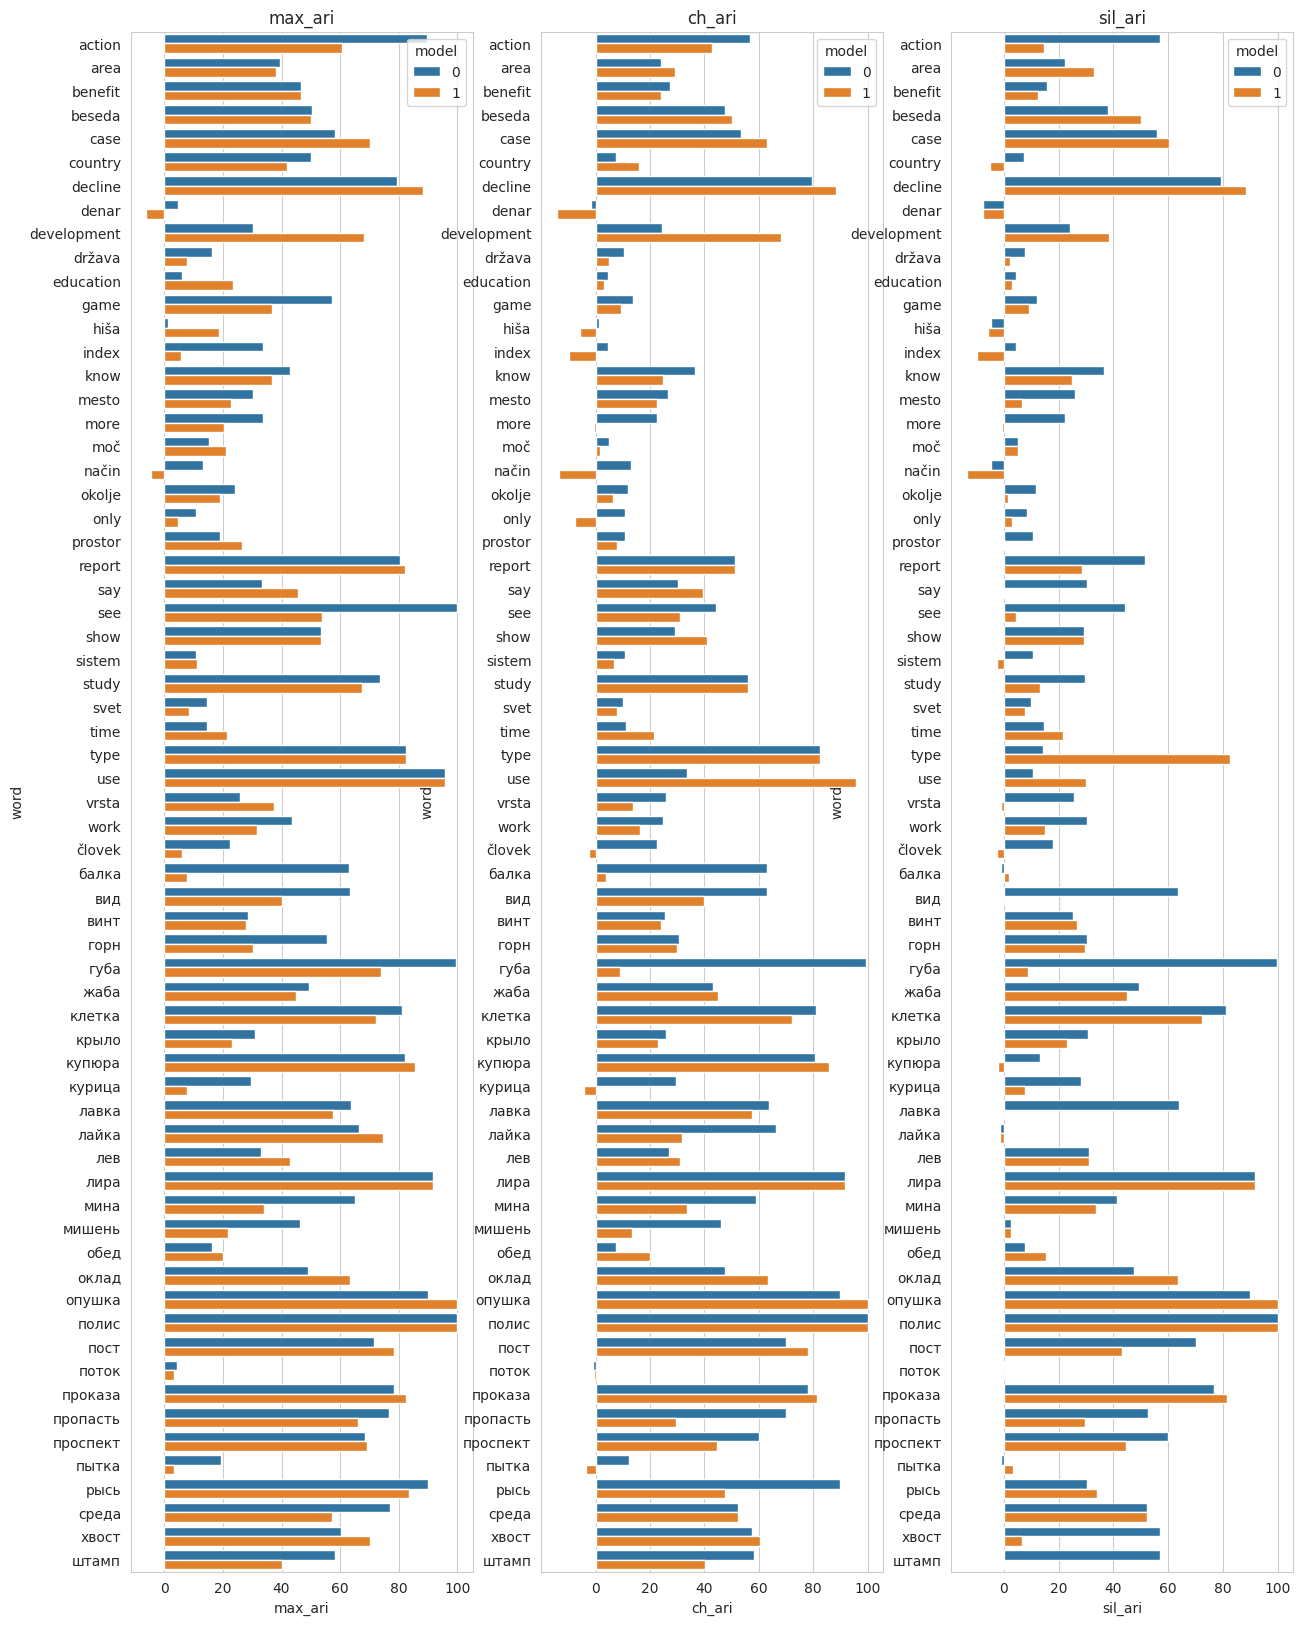

In [32]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 3, figsize=(15, 20))
for i, metric in enumerate(['max_ari', 'ch_ari', 'sil_ari']):
    sns.barplot(data=df, x=metric, hue='model', y='word', ax=ax[i])
    ax[i].set_title(metric)

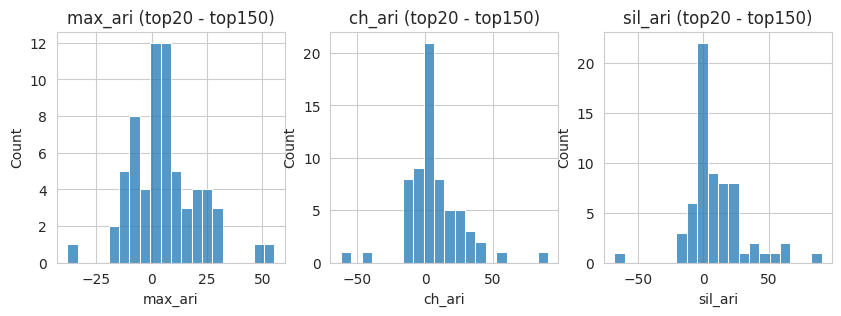

In [38]:
diff = df[df.model == 0].set_index('word') - df[df.model == 1].set_index('word')
fig, ax = plt.subplots(1, 3, figsize=(10, 3))

for i, metric in enumerate(['max_ari', 'ch_ari', 'sil_ari']):
    sns.histplot(data=diff, x=metric, ax=ax[i], bins=20)
    ax[i].set_title(metric + ' (top20 - top150)')

In [22]:
score

,metric,score,hypers,part
3,silhouette_S10_AVG,41.895002,NaN,se10-en-semeval10


In [15]:
from collections import defaultdict
import seaborn as sns

metrics = ['max_ARI']
# 'calinski_harabasz_S10_VMeasure', 'calinski_harabasz_S10_AVG',
datasets=['se10-en-semeval10', 'se13-en-semeval13', "russe_bts-rnc-ru-test-private", 'xl_wsd-sl-test', 'se20lscd_v2-de-sense-old+new']
d = []
params = {
    'cfg': r'(?<=model_vec=).*',
    # 'top_k': '(?<=top_k=)\d+','silhouette_ARI'
    # 'min_df': '(?<=min_df=)\d+\.\d+',
    # 'max_df': '(?<=max_df=)\d+\.\d+',
}
d = []
for f in pth.glob('outputs/*/*test_evaluation*'):
    s = []
    for metric in metrics:
        pth2 = f / 'VectorizingPipeline' / 'agg_metrics' / f"{metric}.tsv"
        if not pth2.is_file():
            pth2 = f / 'LexSubGenAdapter' / 'agg_metrics' / f"{metric}.tsv"
        if not pth2.is_file():
            continue
        if metric == 'max_ARI':
            print(pth2)
        score = pd.read_csv(pth2, sep='\t')
        score = score[score.part.isin(datasets)]
        # if score.shape[0]:
        score['metric'] = metric
        score['cfg'] = [f.name for _ in range(score.shape[0])]
        d.append(score)
        # else:
        #     pth2 = f / 'LexSubGenAdapter' / 'agg_metrics' / f"{metric}.tsv"
        #     if pth2.is_file():
        #         if metric == 'max_ARI':
        #             print(pth2)
        #         score = pd.read_csv(pth2, sep='\t')
        #         score = score[score.part.isin(datasets)]
        #         # if score.shape[0]:
        #         score['metric'] = metric
        #         score[[param for param in params]] = s
        #         d.append(score)
        #     else:
        #         if 'final' in str(f):
        #             print("WHY NOT", f)

df0 = pd.concat(d)
for _, z in df0.groupby(['part', 'cfg']):
    if z.shape[0] > 1 and z.score.nunique() > 1:
        print(z)
df0 = df0.drop_duplicates(subset=['part', 'cfg'])
# df0 = pd.DataFrame(d, columns=list(params.keys()) + ['metric', 'value'])
# df = df0.drop_duplicates(subset=list(params.keys()) + ['part', 'metric'], keep='last')
# df = df.apply(pd.to_numeric, errors='coerce').fillna(df)
# if df.shape[0] != df0.shape:
#     print('found duplicates')
df0

D:\science\summer-wsi\outputs\2023-10-04_00-32-09\+runname=test_evaluation,model_vec=subst_123_and_also\VectorizingPipeline\agg_metrics\max_ARI.tsv
D:\science\summer-wsi\outputs\2023-10-04_00-32-09\+runname=test_evaluation,model_vec=subst_cwm_en_or_even\VectorizingPipeline\agg_metrics\max_ARI.tsv
D:\science\summer-wsi\outputs\2023-10-05_01-15-10\+runname=test_evaluation,model_vec=subst_123_and_also\VectorizingPipeline\agg_metrics\max_ARI.tsv
D:\science\summer-wsi\outputs\2023-10-05_01-15-10\+runname=test_evaluation,model_vec=subst_cwm_en_or_even\VectorizingPipeline\agg_metrics\max_ARI.tsv
D:\science\summer-wsi\outputs\2023-10-07_00-56-26\+runname=test_evaluation,model_vec=subst_123_and_also\VectorizingPipeline\agg_metrics\max_ARI.tsv
D:\science\summer-wsi\outputs\2023-10-07_00-56-26\+runname=test_evaluation,model_vec=subst_cwm_en_or_even\VectorizingPipeline\agg_metrics\max_ARI.tsv
D:\science\summer-wsi\outputs\2023-10-07_00-56-26\+runname=test_evaluation,model_vec=subst_cwm_multi_and_a

,metric,score,hypers,part,cfg
0,max_ARI,39.507071,NaN,se10-en-semeval10,"+runname=test_evaluation,model_vec=subst_123_a..."
1,max_ARI,31.846120,NaN,xl_wsd-sl-test,"+runname=test_evaluation,model_vec=subst_123_a..."
2,max_ARI,62.678803,NaN,russe_bts-rnc-ru-test-private,"+runname=test_evaluation,model_vec=subst_123_a..."
0,max_ARI,44.398447,NaN,se10-en-semeval10,"+runname=test_evaluation,model_vec=subst_cwm_e..."
1,max_ARI,30.220016,NaN,xl_wsd-sl-test,"+runname=test_evaluation,model_vec=subst_cwm_e..."
2,max_ARI,57.839406,NaN,russe_bts-rnc-ru-test-private,"+runname=test_evaluation,model_vec=subst_cwm_e..."
0,max_ARI,38.963819,NaN,se10-en-semeval10,"+runname=test_evaluation,model_vec=subst_cwm_m..."
1,max_ARI,27.886592,NaN,xl_wsd-sl-test,"+runname=test_evaluation,model_vec=subst_cwm_m..."
2,max_ARI,64.576755,NaN,russe_bts-rnc-ru-test-private,"+runname=test_evaluation,model_vec=subst_cwm_m..."
0,max_ARI,41.684515,NaN,se10-en-semeval10,"+runname=test_evaluation,model_vec=subst_cwm_r..."


In [16]:
df0.pivot(index='cfg', columns='part', values='score')

part,russe_bts-rnc-ru-test-private,se10-en-semeval10,se13-en-semeval13,se20lscd_v2-de-sense-old+new,xl_wsd-sl-test
cfg,,,,,
"+runname=test_evaluation,model_vec=lexsubgen",55.171897,33.938685,NaN,NaN,25.069728
"+runname=test_evaluation,model_vec=subst_123_and_also",62.678803,39.507071,38.920547,63.310364,31.846120
"+runname=test_evaluation,model_vec=subst_123_giga",NaN,47.278928,NaN,NaN,NaN
"+runname=test_evaluation,model_vec=subst_123_or_even",59.090655,44.771665,NaN,NaN,31.344567
"+runname=test_evaluation,model_vec=subst_amrami_multilang",45.990813,34.876117,31.835929,46.859967,20.933825
"+runname=test_evaluation,model_vec=subst_cwm_en_or_even",57.839406,44.398447,37.616047,60.644254,30.220016
"+runname=test_evaluation,model_vec=subst_cwm_multi_and_also",64.576755,38.963819,35.288220,57.329437,27.886592
"+runname=test_evaluation,model_vec=subst_cwm_ru_v2_and_also",61.576372,41.684515,36.769882,60.617513,30.709486


In [34]:
sum([38.4, 31.6, 51.6, 47.6, 37.3])/5

41.3

In [36]:
print(df0.pivot(index='cfg', columns='part', values='score')[["russe_bts-rnc-ru-test-private", 'se20lscd_v2-de-sense-old+new', 'xl_wsd-sl-test']].mean(1).to_csv())

cfg,0
"+runname=test_evaluation,model_vec=lexsubgen",31.995332085746092
"+runname=test_evaluation,model_vec=subst_123_and_also",43.38813422645435
"+runname=test_evaluation,model_vec=subst_123_giga",
"+runname=test_evaluation,model_vec=subst_123_or_even",36.751347197290244
"+runname=test_evaluation,model_vec=subst_amrami_multilang",23.77180840998201
"+runname=test_evaluation,model_vec=subst_cwm_en_or_even",37.18481256679933
"+runname=test_evaluation,model_vec=subst_cwm_multi_and_also",38.96648207431266
"+runname=test_evaluation,model_vec=subst_cwm_ru_v2_and_also",40.55671884114934



In [45]:
np.argsort([4,2,3,1], ascending=True)

TypeError: argsort() got an unexpected keyword argument 'ascending'

In [47]:
df0.pivot(index='cfg', columns='part', values='score')[["russe_bts-rnc-ru-test-private", 'se20lscd_v2-de-sense-old+new', 'xl_wsd-sl-test']].apply(lambda x: 6 - np.argsort(x.fillna(44.2)))

part,russe_bts-rnc-ru-test-private,se20lscd_v2-de-sense-old+new,xl_wsd-sl-test
cfg,,,
"+runname=test_evaluation,model_vec=lexsubgen",2,2,2
"+runname=test_evaluation,model_vec=subst_123_and_also",4,0,6
"+runname=test_evaluation,model_vec=subst_123_giga",1,1,0
"+runname=test_evaluation,model_vec=subst_123_or_even",6,6,1
"+runname=test_evaluation,model_vec=subst_amrami_multilang",3,4,3
"+runname=test_evaluation,model_vec=subst_cwm_en_or_even",-1,3,-1
"+runname=test_evaluation,model_vec=subst_cwm_multi_and_also",5,-1,5
"+runname=test_evaluation,model_vec=subst_cwm_ru_v2_and_also",0,5,4


In [55]:
c

,0,1,2
0,35.4,29.3,6.6
1,49.3,38.4,14.7
2,51.6,50.6,21.9
3,48.8,41.2,21.6
4,57.7,39.5,19.7
5,52.0,46.3,23.4


In [67]:
c = pd.DataFrame([
[35.4, 29.3, 6.6],
[49.3, 38.4, 14.7],
[51.6, 50.6, 21.9],
[48.8, 41.2, 21.6],
[57.7, 39.5, 19.7],
[51.0, 46.3, 23.4]
])

print((6 - c.apply(lambda x: np.argsort(np.argsort(x)))).mean(1).to_csv())


,0
0,6.0
1,4.666666666666667
2,1.6666666666666667
3,3.6666666666666665
4,3.0
5,2.0



In [38]:
|print(df0.pivot(index='cfg', columns='part', values='score')[["russe_bts-rnc-ru-test-private", 'se20lscd_v2-de-sense-old+new', 'xl_wsd-sl-test']]
    .assign(avg=df0.pivot(index='cfg', columns='part', values='score')[["russe_bts-rnc-ru-test-private", 'se20lscd_v2-de-sense-old+new', 'xl_wsd-sl-test']].mean(1))
    .style
    .format('{:.1f}')
    .to_latex())

\begin{tabular}{lrrrr}
part & russe_bts-rnc-ru-test-private & se20lscd_v2-de-sense-old+new & xl_wsd-sl-test & avg \\
cfg &  &  &  &  \\
+runname=test_evaluation,model_vec=lexsubgen & 49.3 & nan & 14.7 & 32.0 \\
+runname=test_evaluation,model_vec=subst_123_and_also & 54.4 & 50.6 & 25.2 & 43.4 \\
+runname=test_evaluation,model_vec=subst_123_giga & nan & nan & nan & nan \\
+runname=test_evaluation,model_vec=subst_123_or_even & 51.6 & nan & 21.9 & 36.8 \\
+runname=test_evaluation,model_vec=subst_amrami_multilang & 35.4 & 29.3 & 6.6 & 23.8 \\
+runname=test_evaluation,model_vec=subst_cwm_en_or_even & 48.8 & 41.2 & 21.6 & 37.2 \\
+runname=test_evaluation,model_vec=subst_cwm_multi_and_also & 57.7 & 39.5 & 19.7 & 39.0 \\
+runname=test_evaluation,model_vec=subst_cwm_ru_v2_and_also & 52.0 & 46.3 & 23.4 & 40.6 \\
\end{tabular}



In [11]:
df0.cfg.unique()

array(['+runname=test_evaluation,model_vec=subst_123_and_also',
       '+runname=test_evaluation,model_vec=subst_cwm_en_or_even',
       '+runname=test_evaluation,model_vec=subst_cwm_multi_and_also',
       '+runname=test_evaluation,model_vec=subst_cwm_ru_v2_and_also',
       '+runname=test_evaluation,model_vec=subst_123_or_even',
       '+runname=test_evaluation,model_vec=subst_amrami_multilang',
       '+runname=test_evaluation,model_vec=lexsubgen',
       '+runname=test_evaluation,model_vec=subst_123_giga'], dtype=object)

In [27]:
def get_target_injection_method(cfg_name):
    dp_name = {
        # 'part_of': 'SDP "a part of"',
        # 'due_to': 'SDP "due to"',
        # 'for_example': 'SDP "for example"',
        # 'dp_combine': 'SDP combo',
        # 'amrami_multilang': 'BASELINE amrami',
        # '_1_': "BASELINE 1 mask DP",
        'amrami_multilang': 'baseline',
        'and_also': '"(and also)"',
        'or_even': '"(or even)"',
        'and': '"and"',
        '_or': '"or"',
        'embs': '+embs'
    }
    for dp in dp_name.keys():
        if dp in cfg_name:
            return dp_name[dp]


def get_multimask_method(cfg_name):
    concat_method = {
        # '_1_': "",
        'amrami_multilang': 'baseline',
        '123': 'concat',
        'cwm_ru_v2': 'WCM ru',
        # 'cwm_ru': 'WCM RU',
        'cwm_en': 'WCM en',
        'cwm_multi': 'WCM multi',

    }
    for method in concat_method.keys():
        if method in cfg_name:
            return concat_method[method]

df['target injection'] = df['cfg'].apply(get_target_injection_method)
df['multimask substitutes'] = df['cfg'].apply(get_multimask_method)
df['method'] =df['multimask substitutes'] + ' ' + df['target injection']
df['metric'] = df['metric'].apply(lambda x: x.replace('calinski_harabasz_', '').replace('S10_', ''))
df['part'] = df['part'].replace({'se10-en-semeval10': 'SE10-en', 'russe_bts-rnc-ru-test-private': '{\\shortstack{russe-bts-rnc-ru // test-private}', 'xl_wsd-sl-test': 'xlwsd-sl-test'})
df

,metric,score,hypers,part,cfg,target injection,multimask substitutes,method
0,AVG,49.190404,NaN,SE10-en,_123_and_also,"""(and also)""",concat,"concat ""(and also)"""
1,AVG,45.670257,NaN,xlwsd-sl-test,_123_and_also,"""(and also)""",concat,"concat ""(and also)"""
2,AVG,64.605761,NaN,{\shortstack{russe-bts-rnc-ru // test-private},_123_and_also,"""(and also)""",concat,"concat ""(and also)"""
0,VMeasure,36.300000,NaN,SE10-en,_123_and_also,"""(and also)""",concat,"concat ""(and also)"""
1,VMeasure,39.200000,NaN,xlwsd-sl-test,_123_and_also,"""(and also)""",concat,"concat ""(and also)"""
...,...,...,...,...,...,...,...,...
1,FScore,47.126771,NaN,xlwsd-sl-test,_amrami_multilang,baseline,baseline,baseline baseline
2,FScore,72.446981,NaN,{\shortstack{russe-bts-rnc-ru // test-private},_amrami_multilang,baseline,baseline,baseline baseline
0,ARI,24.212237,NaN,SE10-en,_amrami_multilang,baseline,baseline,baseline baseline
1,ARI,6.589089,NaN,xlwsd-sl-test,_amrami_multilang,baseline,baseline,baseline baseline


In [21]:
df[df.cfg != '_123_and_also'].pivot(index=['part', 'multimask substitutes', 'target injection'], columns='metric', values='score')

metric                                                                calinski_harabasz_ARI  \
part                          multimask substitutes target injection                          
russe_bts-rnc-ru-test-private WCM en                SDP "or even"                 48.807465   
                              WCM multi             SDP "and also"                57.677772   
                              WCM ru                SDP "and also"                52.002357   
                              baseline              baseline                      35.397420   
                              concat                SDP "or even"                 51.555271   
se10-en-semeval10             WCM en                SDP "or even"                 32.212096   
                              WCM multi             SDP "and also"                32.118134   
                              WCM ru                SDP "and also"                33.340576   
                              baseline              baseline                      24.212237   
                              concat                SDP "or even"                 38.355151   
xl_wsd-sl-test                WCM en                SDP "or even"                 21.566974   
                              WCM multi             SDP "and also"                19.702455   
                              WCM ru                SDP "and also"                23.365705   
                              baseline              baseline                       6.589089   
                              concat                SDP "or even"                 21.947423   

metric                                                                calinski_harabasz_S10_AVG  \
part                          multimask substitutes target injection                              
russe_bts-rnc-ru-test-private WCM en                SDP "or even"                     61.765660   
                              WCM multi             SDP "and also"                    66.991311   
                              WCM ru                SDP "and also"                    63.913348   
                              baseline              baseline                          50.066611   
                              concat                SDP "or even"                     62.528963   
se10-en-semeval10             WCM en                SDP "or even"                     49.222044   
                              WCM multi             SDP "and also"                    49.092570   
                              WCM ru                SDP "and also"                    49.372662   
                              baseline              baseline                          43.181381   
                              concat                SDP "or even"                     53.035155   
xl_wsd-sl-test                WCM en                SDP "or even"                     42.452630   
                              WCM multi             SDP "and also"                    40.186353   
                              WCM ru                SDP "and also"                    44.218062   
                              baseline              baseline                          30.546850   
                              concat                SDP "or even"                     43.272450   

metric                                                                calinski_harabasz_S10_FScore  \
part                          multimask substitutes target injection                                 
russe_bts-rnc-ru-test-private WCM en                SDP "or even"                        77.540586   
                              WCM multi             SDP "and also"                       79.712890   
                              WCM ru                SDP "and also"                       77.807924   
                              baseline              baseline                             72.446981   
                              concat                SDP "or even"                       

In [28]:
print(
    (df[df.cfg != '_123_and_also']
     .pivot(index=['part', 'method'], columns='metric', values='score'))
    .style
    .format('{:.1f}')
    .to_latex())

\begin{tabular}{llrrrr}
 & metric & ARI & AVG & FScore & VMeasure \\
part & method &  &  &  &  \\
\multirow[c]{5}{*}{SE10-en} & WCM en "(or even)" & 32.2 & 49.2 & 65.3 & 37.1 \\
 & WCM multi "(and also)" & 32.1 & 49.1 & 66.8 & 36.1 \\
 & WCM ru "(and also)" & 33.3 & 49.4 & 65.5 & 37.2 \\
 & baseline baseline & 24.2 & 43.2 & 62.6 & 29.8 \\
 & concat "(or even)" & 38.4 & 53.0 & 67.1 & 41.9 \\
\multirow[c]{5}{*}{xlwsd-sl-test} & WCM en "(or even)" & 21.6 & 42.5 & 54.1 & 33.3 \\
 & WCM multi "(and also)" & 19.7 & 40.2 & 47.4 & 34.1 \\
 & WCM ru "(and also)" & 23.4 & 44.2 & 51.5 & 38.0 \\
 & baseline baseline & 6.6 & 30.5 & 47.1 & 19.8 \\
 & concat "(or even)" & 21.9 & 43.3 & 52.3 & 35.8 \\
\multirow[c]{5}{*}{{\shortstack{russe-bts-rnc-ru // test-private}} & WCM en "(or even)" & 48.8 & 61.8 & 77.5 & 49.2 \\
 & WCM multi "(and also)" & 57.7 & 67.0 & 79.7 & 56.3 \\
 & WCM ru "(and also)" & 52.0 & 63.9 & 77.8 & 52.5 \\
 & baseline baseline & 35.4 & 50.1 & 72.4 & 34.6 \\
 & concat "(or even)" &

In [11]:
import pickle
np.load("../../SubstWSI_rombek/.lemma_giga/stanza_word/ru_(and_also)_left_cwm_en-3.pkl", allow_pickle=True)

,context,word,lang,positions,word_at,substs_probs
0,"маленькой комнаты. Он был очень высок, наклони...",балка,ru,"(90, 95)",балку,"[(0.03331902623176575, rack), (0.0115483766421..."
1,Пантюхин в Склифе сейчас. Он выползти на улицу...,балка,ru,"(69, 74)",балка,"[(0.028281500563025475, stone), (0.02080214582..."
2,равнозначно обеспечивает и меланхоличную езду....,балка,ru,"(115, 122)",балками,"[(0.019385125255212188, rails), (0.01351669616..."
3,"верхняя часть закрыта, замкнута, многократно о...",балка,ru,"(85, 91)",балкой,"[(0.032726988196372986, rope), (0.015109828673..."
4,"по телевизору: наши гол забили, я вскочил от р...",балка,ru,"(66, 71)",балку,"[(0.029830506071448326, somebody), (0.01660095..."
...,...,...,...,...,...,...
3486,"дурак, но партию свою отрабатывал точно, по ус...",штамп,ru,"(81, 87)",штампы,"[(0.01593652181327343, rulesand), (0.009898632..."
3487,"дело... получается, мыслить и выражать свое мн...",штамп,ru,"(85, 91)",штампу,"[(0.015571551397442818, scriptu), (0.014251042..."
3488,", что актер должен иметь пять штампов-клише ""п...",штамп,ru,"(71, 78)",штампов,"[(0.011236007325351238, jokes), (0.01096851564..."
3489,сегодняшний день в системе негосударственного ...,штамп,ru,"(107, 113)",штампы,"[(0.09436043148161843, elements), (0.074236802..."


In [13]:
np.load("../../SubstWSI_rombek/.lemma_giga/stanza_word/ru_(and_also)_left_cwm_ru-3.pkl", allow_pickle=True)

,context,word,lang,positions,word_at,substs_probs
0,"маленькой комнаты. Он был очень высок, наклони...",балка,ru,"(90, 95)",балку,"[(0.048035889863967896, система), (0.031461883..."
1,Пантюхин в Склифе сейчас. Он выползти на улицу...,балка,ru,"(69, 74)",балка,"[(0.20181308686733246, машина), (0.18904989585..."
2,равнозначно обеспечивает и меланхоличную езду....,балка,ru,"(115, 122)",балками,"[(0.09496700018644333, диск), (0.0623003393411..."
3,"верхняя часть закрыта, замкнута, многократно о...",балка,ru,"(85, 91)",балкой,"[(0.13729548454284668, крыша), (0.050396202364..."
4,"по телевизору: наши гол забили, я вскочил от р...",балка,ru,"(66, 71)",балку,"[(0.11207965738140047, стена), (0.094380616021..."
...,...,...,...,...,...,...
3486,"дурак, но партию свою отрабатывал точно, по ус...",штамп,ru,"(81, 87)",штампы,"[(0.48019346850924194, правило), (0.2019814290..."
3487,"дело... получается, мыслить и выражать свое мн...",штамп,ru,"(85, 91)",штампу,"[(0.07238979649264365, правило), (0.0490256063..."
3488,", что актер должен иметь пять штампов-клише ""п...",штамп,ru,"(71, 78)",штампов,"[(0.09260483831167221, линия), (0.056158334016..."
3489,сегодняшний день в системе негосударственного ...,штамп,ru,"(107, 113)",штампы,"[(0.4251868724822998, след), (0.11654188274405..."


In [6]:
from collections import defaultdict
import seaborn as sns

metrics = ['calinski_harabasz_S13_FNMI', 'calinski_harabasz_S13_F1', 'calinski_harabasz_S13_AVG']
# 'calinski_harabasz_S10_VMeasure', 'calinski_harabasz_S10_AVG',
datasets=['se13-en-semeval13']
d = []
params = {
    'cfg': r'(?<=model_vec=subst).*',
    # 'top_k': '(?<=top_k=)\d+','silhouette_ARI'
    # 'min_df': '(?<=min_df=)\d+\.\d+',
    # 'max_df': '(?<=max_df=)\d+\.\d+',
}
d = []
for f in pth.glob('outputs/*/*test_evaluation*'):
    s = []
    for param, pattern in params.items():
        value = re.search(pattern, str(f))
        if value:
            s.append(value[0])
    for metric in metrics:
        pth2 = f / 'VectorizingPipeline' / 'agg_metrics' / f"{metric}.tsv"
        if pth2.is_file():
            print(pth2)
            score = pd.read_csv(pth2, sep='\t')
            score = score[score.part.isin(datasets)]
            # if score.shape[0]:
            score['metric'] = metric
            score[[param for param in params]] = s
            d.append(score)
        # else:
        #     pth2 = f / 'LexSubGenAdapter' / 'agg_metrics' / f"{metric}.tsv"
        #     if pth2.is_file():
        #         if metric == 'max_ARI':
        #             print(pth2)
        #         score = pd.read_csv(pth2, sep='\t')
        #         score = score[score.part.isin(datasets)]
        #     if score.shape[0]:
        #         score['metric'] = metric
        #         score[[param for param in params]] = s
        #         d.append(score)
            # else:
            #     if 'final' in str(f):
            #         print("WHY NOT", f)

df0 = pd.concat(d)
# df0 = pd.DataFrame(d, columns=list(params.keys()) + ['metric', 'value'])
df = df0.drop_duplicates(subset=list(params.keys()) + ['part', 'metric'], keep='last')
df = df.apply(pd.to_numeric, errors='coerce').fillna(df)
if df.shape[0] != df0.shape:
    print('found duplicates')
df

/mnt/d/science/summer-wsi/outputs/2023-10-04_00-32-09/+runname=test_evaluation,model_vec=subst_123_and_also/VectorizingPipeline/agg_metrics/calinski_harabasz_S13_FNMI.tsv
/mnt/d/science/summer-wsi/outputs/2023-10-04_00-32-09/+runname=test_evaluation,model_vec=subst_123_and_also/VectorizingPipeline/agg_metrics/calinski_harabasz_S13_F1.tsv
/mnt/d/science/summer-wsi/outputs/2023-10-04_00-32-09/+runname=test_evaluation,model_vec=subst_123_and_also/VectorizingPipeline/agg_metrics/calinski_harabasz_S13_AVG.tsv
/mnt/d/science/summer-wsi/outputs/2023-10-04_00-32-09/+runname=test_evaluation,model_vec=subst_cwm_en_or_even/VectorizingPipeline/agg_metrics/calinski_harabasz_S13_FNMI.tsv
/mnt/d/science/summer-wsi/outputs/2023-10-04_00-32-09/+runname=test_evaluation,model_vec=subst_cwm_en_or_even/VectorizingPipeline/agg_metrics/calinski_harabasz_S13_F1.tsv
/mnt/d/science/summer-wsi/outputs/2023-10-04_00-32-09/+runname=test_evaluation,model_vec=subst_cwm_en_or_even/VectorizingPipeline/agg_metrics/cali

,metric,score,hypers,part,cfg
0,calinski_harabasz_S13_FNMI,19.365257,NaN,se13-en-semeval13,_123_and_also
0,calinski_harabasz_S13_F1,65.146503,NaN,se13-en-semeval13,_123_and_also
0,calinski_harabasz_S13_AVG,35.518710,NaN,se13-en-semeval13,_123_and_also
0,calinski_harabasz_S13_FNMI,14.717529,NaN,se13-en-semeval13,_amrami_multilang
0,calinski_harabasz_S13_F1,60.685445,NaN,se13-en-semeval13,_amrami_multilang
0,calinski_harabasz_S13_AVG,29.885444,NaN,se13-en-semeval13,_amrami_multilang
0,calinski_harabasz_S13_FNMI,17.695935,NaN,se13-en-semeval13,_cwm_en_or_even
0,calinski_harabasz_S13_F1,63.984125,NaN,se13-en-semeval13,_cwm_en_or_even
0,calinski_harabasz_S13_AVG,33.649056,NaN,se13-en-semeval13,_cwm_en_or_even
0,calinski_harabasz_S13_FNMI,17.465053,NaN,se13-en-semeval13,_cwm_ru_v2_and_also


In [70]:
from collections import defaultdict
import seaborn as sns

metrics = ['calinski_harabasz_S10_FScore', 'calinski_harabasz_S10_VMeasure', 'calinski_harabasz_S10_AVG']
# 'calinski_harabasz_S10_VMeasure', 'calinski_harabasz_S10_AVG',
datasets=['se10-en-semeval10']
d = []
params = {
    'cfg': r'(?<=model_vec=).*',
    # 'top_k': '(?<=top_k=)\d+','silhouette_ARI'
    # 'min_df': '(?<=min_df=)\d+\.\d+',
    # 'max_df': '(?<=max_df=)\d+\.\d+',
}
d = []
for f in pth.glob('outputs/*/*test_evaluation*'):
    s = []
    for metric in metrics:
        pth2 = f / 'VectorizingPipeline' / 'agg_metrics' / f"{metric}.tsv"
        if not pth2.is_file():
            pth2 = f / 'LexSubGenAdapter' / 'agg_metrics' / f"{metric}.tsv"
        if not pth2.is_file():
            continue
        if metric == 'max_ARI':
            print(pth2)
        score = pd.read_csv(pth2, sep='\t')
        score = score[score.part.isin(datasets)]
        # if score.shape[0]:
        score['metric'] = metric
        score['cfg'] = [f.name for _ in range(score.shape[0])]
        d.append(score)
        # else:
        #     pth2 = f / 'LexSubGenAdapter' / 'agg_metrics' / f"{metric}.tsv"
        #     if pth2.is_file():
        #         if metric == 'max_ARI':
        #             print(pth2)
        #         score = pd.read_csv(pth2, sep='\t')
        #         score = score[score.part.isin(datasets)]
        #         # if score.shape[0]:
        #         score['metric'] = metric
        #         score[[param for param in params]] = s
        #         d.append(score)
        #     else:
        #         if 'final' in str(f):
        #             print("WHY NOT", f)

df0 = pd.concat(d)
for _, z in df0.groupby(['part', 'cfg']):
    if z.shape[0] > 1 and z.score.nunique() > 1:
        print(z)
df0 = df0.drop_duplicates(subset=['part', 'cfg', 'metric'])
# df0 = pd.DataFrame(d, columns=list(params.keys()) + ['metric', 'value'])
# df = df0.drop_duplicates(subset=list(params.keys()) + ['part', 'metric'], keep='last')
# df = df.apply(pd.to_numeric, errors='coerce').fillna(df)
# if df.shape[0] != df0.shape:
#     print('found duplicates')
df0

                           metric      score  hypers               part  \
0    calinski_harabasz_S10_FScore  63.147176     NaN  se10-en-semeval10   
0  calinski_harabasz_S10_VMeasure  33.800000     NaN  se10-en-semeval10   
0       calinski_harabasz_S10_AVG  46.199292     NaN  se10-en-semeval10   

                                            cfg  
0  +runname=test_evaluation,model_vec=lexsubgen  
0  +runname=test_evaluation,model_vec=lexsubgen  
0  +runname=test_evaluation,model_vec=lexsubgen  
                           metric      score  hypers               part  \
0    calinski_harabasz_S10_FScore  66.658286     NaN  se10-en-semeval10   
0  calinski_harabasz_S10_VMeasure  36.300000     NaN  se10-en-semeval10   
0       calinski_harabasz_S10_AVG  49.190404     NaN  se10-en-semeval10   
0    calinski_harabasz_S10_FScore  66.658286     NaN  se10-en-semeval10   
0  calinski_harabasz_S10_VMeasure  36.300000     NaN  se10-en-semeval10   
0       calinski_harabasz_S10_AVG  49.190404     

,metric,score,hypers,part,cfg
0,calinski_harabasz_S10_FScore,66.658286,NaN,se10-en-semeval10,"+runname=test_evaluation,model_vec=subst_123_a..."
0,calinski_harabasz_S10_VMeasure,36.300000,NaN,se10-en-semeval10,"+runname=test_evaluation,model_vec=subst_123_a..."
0,calinski_harabasz_S10_AVG,49.190404,NaN,se10-en-semeval10,"+runname=test_evaluation,model_vec=subst_123_a..."
0,calinski_harabasz_S10_FScore,65.304842,NaN,se10-en-semeval10,"+runname=test_evaluation,model_vec=subst_cwm_e..."
0,calinski_harabasz_S10_VMeasure,37.100000,NaN,se10-en-semeval10,"+runname=test_evaluation,model_vec=subst_cwm_e..."
0,calinski_harabasz_S10_AVG,49.222044,NaN,se10-en-semeval10,"+runname=test_evaluation,model_vec=subst_cwm_e..."
0,calinski_harabasz_S10_FScore,66.761230,NaN,se10-en-semeval10,"+runname=test_evaluation,model_vec=subst_cwm_m..."
0,calinski_harabasz_S10_VMeasure,36.100000,NaN,se10-en-semeval10,"+runname=test_evaluation,model_vec=subst_cwm_m..."
0,calinski_harabasz_S10_AVG,49.092570,NaN,se10-en-semeval10,"+runname=test_evaluation,model_vec=subst_cwm_m..."
0,calinski_harabasz_S10_FScore,65.528488,NaN,se10-en-semeval10,"+runname=test_evaluation,model_vec=subst_cwm_r..."


In [77]:
from collections import defaultdict
import seaborn as sns

metrics = ['calinski_harabasz_S13_F1', 'calinski_harabasz_S13_FNMI', 'calinski_harabasz_S13_AVG']
# 'calinski_harabasz_S10_VMeasure', 'calinski_harabasz_S10_AVG',
datasets=['se13-en-semeval13']
d = []
params = {
    'cfg': r'(?<=model_vec=).*',
    # 'top_k': '(?<=top_k=)\d+','silhouette_ARI'
    # 'min_df': '(?<=min_df=)\d+\.\d+',
    # 'max_df': '(?<=max_df=)\d+\.\d+',
}
d = []
for f in pth.glob('outputs/*/*test_evaluation*'):
    s = []
    for metric in metrics:
        pth2 = f / 'VectorizingPipeline' / 'agg_metrics' / f"{metric}.tsv"
        if not pth2.is_file():
            pth2 = f / 'LexSubGenAdapter' / 'agg_metrics' / f"{metric}.tsv"
        if not pth2.is_file():
            continue
        if metric == 'max_ARI':
            print(pth2)
        score = pd.read_csv(pth2, sep='\t')
        score = score[score.part.isin(datasets)]
        # if score.shape[0]:
        score['metric'] = metric
        score['cfg'] = [f.name for _ in range(score.shape[0])]
        d.append(score)
        # else:
        #     pth2 = f / 'LexSubGenAdapter' / 'agg_metrics' / f"{metric}.tsv"
        #     if pth2.is_file():
        #         if metric == 'max_ARI':
        #             print(pth2)
        #         score = pd.read_csv(pth2, sep='\t')
        #         score = score[score.part.isin(datasets)]
        #         # if score.shape[0]:
        #         score['metric'] = metric
        #         score[[param for param in params]] = s
        #         d.append(score)
        #     else:
        #         if 'final' in str(f):
        #             print("WHY NOT", f)

df0 = pd.concat(d)
for _, z in df0.groupby(['part', 'cfg']):
    if z.shape[0] > 1 and z.score.nunique() > 1:
        print(z)
df0 = df0.drop_duplicates(subset=['part', 'cfg', 'metric'])
# df0 = pd.DataFrame(d, columns=list(params.keys()) + ['metric', 'value'])
# df = df0.drop_duplicates(subset=list(params.keys()) + ['part', 'metric'], keep='last')
# df = df.apply(pd.to_numeric, errors='coerce').fillna(df)
# if df.shape[0] != df0.shape:
#     print('found duplicates')
df0

                       metric      score  hypers               part  \
0    calinski_harabasz_S13_F1  65.146503     NaN  se13-en-semeval13   
0  calinski_harabasz_S13_FNMI  19.365257     NaN  se13-en-semeval13   
0   calinski_harabasz_S13_AVG  35.518710     NaN  se13-en-semeval13   

                                                 cfg  
0  +runname=test_evaluation,model_vec=subst_123_a...  
0  +runname=test_evaluation,model_vec=subst_123_a...  
0  +runname=test_evaluation,model_vec=subst_123_a...  
                       metric      score  hypers               part  \
0    calinski_harabasz_S13_F1  60.685445     NaN  se13-en-semeval13   
0  calinski_harabasz_S13_FNMI  14.717529     NaN  se13-en-semeval13   
0   calinski_harabasz_S13_AVG  29.885444     NaN  se13-en-semeval13   

                                                 cfg  
0  +runname=test_evaluation,model_vec=subst_amram...  
0  +runname=test_evaluation,model_vec=subst_amram...  
0  +runname=test_evaluation,model_vec=subst_a

,metric,score,hypers,part,cfg
0,calinski_harabasz_S13_F1,65.146503,NaN,se13-en-semeval13,"+runname=test_evaluation,model_vec=subst_123_a..."
0,calinski_harabasz_S13_FNMI,19.365257,NaN,se13-en-semeval13,"+runname=test_evaluation,model_vec=subst_123_a..."
0,calinski_harabasz_S13_AVG,35.518710,NaN,se13-en-semeval13,"+runname=test_evaluation,model_vec=subst_123_a..."
0,calinski_harabasz_S13_F1,60.685445,NaN,se13-en-semeval13,"+runname=test_evaluation,model_vec=subst_amram..."
0,calinski_harabasz_S13_FNMI,14.717529,NaN,se13-en-semeval13,"+runname=test_evaluation,model_vec=subst_amram..."
0,calinski_harabasz_S13_AVG,29.885444,NaN,se13-en-semeval13,"+runname=test_evaluation,model_vec=subst_amram..."
0,calinski_harabasz_S13_F1,63.984125,NaN,se13-en-semeval13,"+runname=test_evaluation,model_vec=subst_cwm_e..."
0,calinski_harabasz_S13_FNMI,17.695935,NaN,se13-en-semeval13,"+runname=test_evaluation,model_vec=subst_cwm_e..."
0,calinski_harabasz_S13_AVG,33.649056,NaN,se13-en-semeval13,"+runname=test_evaluation,model_vec=subst_cwm_e..."
0,calinski_harabasz_S13_F1,63.016540,NaN,se13-en-semeval13,"+runname=test_evaluation,model_vec=subst_cwm_r..."


In [78]:
df0.pivot(index='cfg', columns=['metric'], values='score')[metrics]

metric,calinski_harabasz_S13_F1,calinski_harabasz_S13_FNMI,calinski_harabasz_S13_AVG
cfg,,,
"+runname=test_evaluation,model_vec=subst_123_and_also",65.146503,19.365257,35.518710
"+runname=test_evaluation,model_vec=subst_amrami_multilang",60.685445,14.717529,29.885444
"+runname=test_evaluation,model_vec=subst_cwm_en_or_even",63.984125,17.695935,33.649056
"+runname=test_evaluation,model_vec=subst_cwm_multi_and_also",63.893621,17.020365,32.977155
"+runname=test_evaluation,model_vec=subst_cwm_ru_v2_and_also",63.016540,17.465053,33.175099


In [2]:
import os
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib

matplotlib.rcParams['figure.dpi'] = 150
import re

import torch
import torch.hub
from transformers import AutoTokenizer
import re

from string import punctuation

from collections import Counter
from tqdm import tqdm
import numpy as np
import seaborn as sns

pth = Path(r'../..').resolve()
pth


PosixPath('/mnt/d/science/summer-wsi')

In [5]:
from collections import defaultdict
import seaborn as sns
import yaml

metrics = [
    'calinski_harabasz_S10_Completeness',
    'calinski_harabasz_S10_Homogeneity',
    'calinski_harabasz_S10_Precision',
    'calinski_harabasz_S10_Recall',


] #''calinski_harabasz_S10_AVG', 'calinski_harabasz_S10_VMeasure', 'calinski_harabasz_S10_FScore', 'calinski_harabasz_ARI']

d = []
for f in pth.glob('outputs/2023-10-1[56]*'):
    search = list(f.rglob('*VectorizingPipeline'))
    if search:
    # for param, pattern in params.items():
    #     value = re.search(pattern, str(f))
    #     if value:
    #         s.append(value[0])
        f = search[0]
        try:
            with open(f / '..' / '.hydra' / 'overrides.yaml', 'r') as t:
                conf = yaml.safe_load(t)
                print(conf)
        except:
            continue
        print(f)
        for metric in metrics:

            pth2 = f / 'agg_metrics' / f"{metric}.tsv"
            print(pth2)
            if pth2.is_file():
                if metric == 'max_ARI':
                    print(pth2)
                score = pd.read_csv(pth2, sep='\t')
                score['conf'] = str(conf)
                d.append(score)

df0 = pd.concat(d)
# df0 = pd.DataFrame(d, columns=list(params.keys()) + ['metric', 'value'])
# df = df0.drop_duplicates(subset=list(params.keys()) + ['part', 'metric'], keep='last')
# df = df.apply(pd.to_numeric, errors='coerce').fillna(df)
# if df.shape[0] != df0.shape:
#     print('found duplicates')
df0

['model_vec=subst_123_giga', '+runname=test_evaluation']
/mnt/d/science/summer-wsi/outputs/2023-10-15_10-49-53/+runname=test_evaluation,model_vec=subst_123_giga/VectorizingPipeline
/mnt/d/science/summer-wsi/outputs/2023-10-15_10-49-53/+runname=test_evaluation,model_vec=subst_123_giga/VectorizingPipeline/agg_metrics/calinski_harabasz_S10_Completeness.tsv
/mnt/d/science/summer-wsi/outputs/2023-10-15_10-49-53/+runname=test_evaluation,model_vec=subst_123_giga/VectorizingPipeline/agg_metrics/calinski_harabasz_S10_Homogeneity.tsv
/mnt/d/science/summer-wsi/outputs/2023-10-15_10-49-53/+runname=test_evaluation,model_vec=subst_123_giga/VectorizingPipeline/agg_metrics/calinski_harabasz_S10_Precision.tsv
/mnt/d/science/summer-wsi/outputs/2023-10-15_10-49-53/+runname=test_evaluation,model_vec=subst_123_giga/VectorizingPipeline/agg_metrics/calinski_harabasz_S10_Recall.tsv
['model_vec=subst_123_giga', '+runname=test_evaluation']
/mnt/d/science/summer-wsi/outputs/2023-10-15_12-14-21/+runname=test_eval

,metric,score,hypers,part,conf
0,calinski_harabasz_S10_Completeness,-100.0,NaN,se10-en-semeval10,"['model_vec=subst_123_giga', '+runname=test_ev..."
0,calinski_harabasz_S10_Homogeneity,-100.0,NaN,se10-en-semeval10,"['model_vec=subst_123_giga', '+runname=test_ev..."
0,calinski_harabasz_S10_Precision,-100.0,NaN,se10-en-semeval10,"['model_vec=subst_123_giga', '+runname=test_ev..."
0,calinski_harabasz_S10_Recall,-100.0,NaN,se10-en-semeval10,"['model_vec=subst_123_giga', '+runname=test_ev..."
0,calinski_harabasz_S10_Completeness,-100.0,NaN,se10-en-semeval10,"['model_vec=subst_123_giga', '+runname=test_ev..."
...,...,...,...,...,...
0,calinski_harabasz_S10_Recall,-100.0,NaN,se20lscd_v2-de-sense-old+new,"['model_vec=subst_cwm_ru_v2_and_also', '+runna..."
0,calinski_harabasz_S10_Completeness,-100.0,NaN,se20lscd_v2-de-sense-old+new,"['model_vec=subst_cwm_multi_and_also', '+runna..."
0,calinski_harabasz_S10_Homogeneity,-100.0,NaN,se20lscd_v2-de-sense-old+new,"['model_vec=subst_cwm_multi_and_also', '+runna..."
0,calinski_harabasz_S10_Precision,-100.0,NaN,se20lscd_v2-de-sense-old+new,"['model_vec=subst_cwm_multi_and_also', '+runna..."
